In [1]:
# auto update source files before running cells
%load_ext autoreload
%autoreload 2

# Student-t VAR Noise Model Investigation

Comparing METEOR ensemble output with **normal** vs **Student-t** distributed VAR errors.

Goals:
1. Train emulators with both `noise_pc_distribution='normal'` and `noise_pc_distribution='t'`
2. Compare ensemble spread, tail behaviour, and kurtosis
3. Rank histogram analysis against CMIP6 data
4. Investigate effect of different degrees of freedom

## 0. Setup and imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from meteor import MeteorInterface, Cmip6MeteorDataGetter, geo_data_utils

print("Imports complete")

Imports complete


In [3]:
MACHINE = "ivan/mimi/victor"  # ivan/mimi/victor, local

if MACHINE == "ivan/mimi/victor":
    cache_dir = Path("/scratch/johannlf")
else:
    from fys9429 import PROJECT_ROOT
    cache_dir = PROJECT_ROOT.joinpath("cache")

FIGURE_DIR = 'figures'
os.makedirs(FIGURE_DIR, exist_ok=True)
print(f"Cache dir: {cache_dir}")
print(f"Figure dir: {os.path.abspath(FIGURE_DIR)}")

Cache dir: /scratch/johannlf
Figure dir: /uio/kant/geo-geofag-u1/johannlf/FYS9429/investigations/monthly_output/figures


## 1. Configuration

In [5]:
MODEL = 'NorESM2-MM'
VARIABLES = ['tas']
N_REALIZATIONS = 300
SCENARIO = 'ssp245'
START_YEAR = 1850
END_YEAR = 2100

regions = ['NEU', 'NSA', 'EAS']
region_names = {
    'NEU': 'Northern Europe',
    'NSA': 'Northern South America',
    'EAS': 'East Asia'
}

cities = {
    'Oslo': {'lat': 59.9, 'lon': 10.8},
    'Delhi': {'lat': 28.6, 'lon': 77.2},
    'Cairo': {'lat': 30.0, 'lon': 31.2},
    'Beijing': {'lat': 39.9, 'lon': 116.4}
}

timeseries = ['global']
timeseries += [f'regional:{r}' for r in regions]
timeseries += [f"point:{cities[c]['lat']},{cities[c]['lon']}" for c in cities.keys()]

print(f"Model: {MODEL}")
print(f"Variables: {VARIABLES}")
print(f"Spatial aggregations: {len(timeseries)}")
for ts in timeseries:
    print(f"  {ts}")

Model: NorESM2-MM
Variables: ['tas']
Spatial aggregations: 8
  global
  regional:NEU
  regional:NSA
  regional:EAS
  point:59.9,10.8
  point:28.6,77.2
  point:30.0,31.2
  point:39.9,116.4


## 2. Load CMIP6 reference data

Load CMIP6 "truth" for rank histogram comparison.

In [6]:
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "historical", "ssp245", "ssp126", "ssp585"],
    flds=['tas'],
    dbe=['CMIP', 'CMIP', 'ScenarioMIP', 'ScenarioMIP', 'ScenarioMIP'],
    enable_cache=True
)

cmip6_data_raw = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], MODEL, monthly=True
)
picontrol_data = data_getter.make_meteor_training_data(
    "piControl", MODEL, monthly=True
)

# Build anomaly time series (TAS)
cmip6_timeseries = {}
cmip6_point_data = {}

# Global
cmip6_global_abs = geo_data_utils.global_mean(cmip6_data_raw['tas'])
picontrol_global = geo_data_utils.global_mean(picontrol_data['tas'])
picontrol_baseline = picontrol_global.mean()
cmip6_timeseries['global'] = cmip6_global_abs - picontrol_baseline

# Regions
for region in regions:
    cmip6_reg_abs = geo_data_utils.regional_mean(cmip6_data_raw['tas'], region)
    picontrol_reg = geo_data_utils.regional_mean(picontrol_data['tas'], region)
    cmip6_timeseries[f'regional:{region}'] = cmip6_reg_abs - picontrol_reg.mean()

# Points
for city_name, coords in cities.items():
    key = f"point:{coords['lat']},{coords['lon']}"
    cmip6_pt = geo_data_utils.extract_point(cmip6_data_raw['tas'], coords['lat'], coords['lon'])
    picontrol_pt = geo_data_utils.extract_point(picontrol_data['tas'], coords['lat'], coords['lon'])
    cmip6_point_data[key] = cmip6_pt - picontrol_pt.mean()

print(f"CMIP6 TAS shape: {cmip6_data_raw['tas'].shape}")
print(f"Point locations loaded: {len(cmip6_point_data)}")

CMIP6 TAS shape: (1, 3012, 192, 288)
Point locations loaded: 4


## 3. Train emulators: Normal vs Student-t

Train two METEOR emulators:
- **Normal**: standard MVN errors (default)
- **Student-t**: `noise_pc_distribution='t'`, `t_df=mle`

In [10]:
# --- Normal emulator ---
emu_normal = MeteorInterface(model=MODEL, variables=VARIABLES, cache_dir=cache_dir)
emu_normal.train(verbose=True)
print("Normal emulator trained.\n")

# --- Student-t emulator ---
t_configs = {'tas': {'noise_pc_distribution': 't', 't_df': 'mle'}}
emu_t = MeteorInterface(model=MODEL, variables=VARIABLES, cache_dir=cache_dir)
emu_t.train(variable_configs=t_configs, verbose=True)
print("Student-t emulator trained.")

Training METEOR emulator for NorESM2-MM
Variables: tas

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-NorESM2-MM-aer', found 'cmip6-NorESM2-MM-aer-tas'
🔧 Preparing pattern scaling training data for NorESM2-MM...
   ✅ Training data prepared for experiments:  ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 351 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from /scratch/johannlf/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
✅ Pattern scaling model loaded from /scratch/johannlf/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
   → Training noise model...
Model loaded from /scratch/johannlf/noise_models/NorESM2-MM_tas_noise_model.pkl
      ✓ Using cached noise model
   ✅ TAS training complete

✅ All variables trained successfully
Normal emulator traine

## 3b. Per-PC kurtosis of VARX residuals

Extract the VARX residuals from the trained **normal** noise model and inspect
excess kurtosis per principal component.  If some PCs show significantly
heavier tails than others, that motivates fitting a separate Student-t df
per PC rather than a single global df.

VARX residuals shape: (3010, 40)


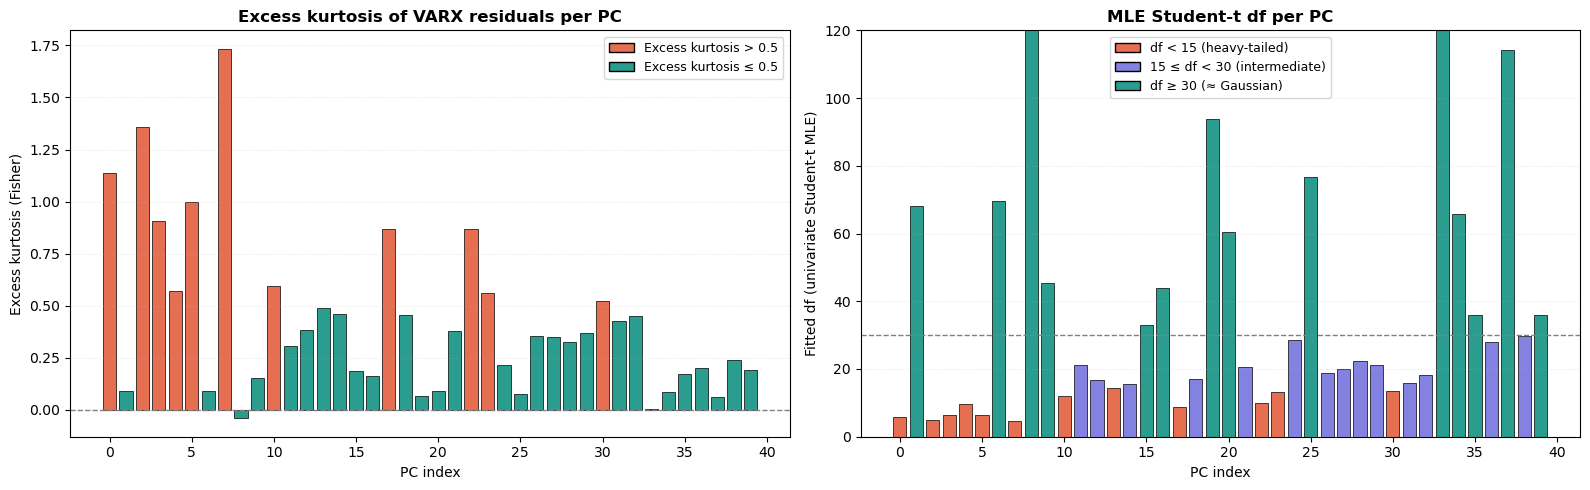


Excess kurtosis — mean: 0.423, max: 1.733 (PC 7), min: -0.040 (PC 8)
MLE df — median: 20.9, min: 4.7 (PC 7), max: 6687639496.0 (PC 8)
12/40 PCs with fitted df < 15


In [26]:
from scipy.stats import kurtosis as scipy_kurtosis, t as scipy_t

noise_model = emu_normal.noise_models['tas']
residuals = noise_model.varx_results.resid   # (n_obs, n_modes)
n_obs, n_modes = residuals.shape
print(f"VARX residuals shape: {residuals.shape}")

# --- Excess kurtosis per PC ---
pc_kurtosis = scipy_kurtosis(residuals, axis=0, fisher=True)

# --- Per-PC univariate MLE for Student-t df ---
pc_best_df = np.zeros(n_modes)
for j in range(n_modes):
    r = residuals[:, j]
    df_fit, _, _ = scipy_t.fit(r)
    pc_best_df[j] = df_fit

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
colors = ['#E76F51' if k > 0.5 else '#2A9D8F' for k in pc_kurtosis]
ax.bar(range(n_modes), pc_kurtosis, color=colors, edgecolor='black', lw=0.5)
ax.axhline(0, color='grey', ls='--', lw=1)
ax.set_xlabel('PC index')
ax.set_ylabel('Excess kurtosis (Fisher)')
ax.set_title('Excess kurtosis of VARX residuals per PC', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y', ls=':')
# add legend manually
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E76F51', edgecolor='black', label='Excess kurtosis > 0.5'),
    Patch(facecolor='#2A9D8F', edgecolor='black', label='Excess kurtosis ≤ 0.5')
]
ax.legend(handles=legend_elements, fontsize=9)

ax = axes[1]
colors2 = ['#E76F51' if d < 15 else ("#8482E0" if 15 <= d < 30 else '#2A9D8F') for d in pc_best_df]
ax.bar(range(n_modes), pc_best_df, color=colors2, edgecolor='black', lw=0.5)
ax.axhline(30, color='grey', ls='--', lw=1, label='df=30 (≈ Gaussian)')
ax.set_xlabel('PC index')
ax.set_ylabel('Fitted df (univariate Student-t MLE)')
ax.set_title('MLE Student-t df per PC', fontweight='bold')
ax.set_ylim([0, min(120, pc_best_df.max() * 1.2)])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y', ls=':')
# color code: red for df < 15 (heavy-tailed), blue for df ≥ 30 (≈ Gaussian), purple for intermediate
legend_elements2 = [
      Patch(facecolor='#E76F51', edgecolor='black', label='df < 15 (heavy-tailed)'),
      Patch(facecolor='#8482E0', edgecolor='black', label='15 ≤ df < 30 (intermediate)'),
      Patch(facecolor='#2A9D8F', edgecolor='black', label='df ≥ 30 (≈ Gaussian)')
]
ax.legend(handles=legend_elements2, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'pc_kurtosis_and_df_tas.pdf'), bbox_inches='tight', dpi=200)
plt.show()

print(f"\nExcess kurtosis — mean: {pc_kurtosis.mean():.3f}, "
      f"max: {pc_kurtosis.max():.3f} (PC {pc_kurtosis.argmax()}), "
      f"min: {pc_kurtosis.min():.3f} (PC {pc_kurtosis.argmin()})")
print(f"MLE df — median: {np.median(pc_best_df):.1f}, "
      f"min: {pc_best_df.min():.1f} (PC {pc_best_df.argmin()}), "
      f"max: {pc_best_df.max():.1f} (PC {pc_best_df.argmax()})")
n_heavy = (pc_best_df < 15).sum()
print(f"{n_heavy}/{n_modes} PCs with fitted df < 15")

## 4. Generate ensembles

Same scenario, spatial aggregations, number of realizations for both.

In [12]:
gen_kwargs = dict(
    scenario=SCENARIO,
    start_year=START_YEAR,
    end_year=END_YEAR,
    n_realizations=N_REALIZATIONS,
    timeseries=timeseries,
    verbose=True,
)

ens_normal = emu_normal.generate_ensemble_outputs(**gen_kwargs)
print(f"Normal ensemble: {N_REALIZATIONS} realisations\n")

ens_t = emu_t.generate_ensemble_outputs(**gen_kwargs)
print(f"Student-t ensemble: {N_REALIZATIONS} realisations")

# Print the per-PC MLE-selected df
fitted_df_arr = emu_t.noise_models['tas']._fitted_df
med = np.median(fitted_df_arr)
t_label = f'Student-t (per-PC, median df={med:.0f})'
n_heavy = (fitted_df_arr < 15).sum()
print(f"\nPer-PC fitted df (median={med:.1f}):")
print(f"  {np.array2string(fitted_df_arr, precision=1, separator=', ')}")
print(f"  {n_heavy}/{len(fitted_df_arr)} PCs with df < 15")

Generating ensemble for ssp245
  Years: 1850-2100
  Realizations: 300

📊 Generating TAS...
   → Time series: 8 aggregations
      → Computing pattern scaling for tas, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 300 stochastic PC realizations...
      • global
      • regional:NEU
      • regional:NSA
      • regional:EAS
      • point:59.9,10.8
      • point:28.6,77.2
      • point:30.0,31.2
      • point:39.9,116.4
   ✅ TAS complete

✅ Generation complete
Normal ensemble: 300 realisations

Generating ensemble for ssp245
  Years: 1850-2100
  Realizations: 300

📊 Generating TAS...
   → Time series: 8 aggregations
      → Computing pattern scaling for tas, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 300 s

## 5. Time-series comparison: Normal vs Student-t

Overlay percentile fans from both emulators and the CMIP6 reference for a selection of locations.

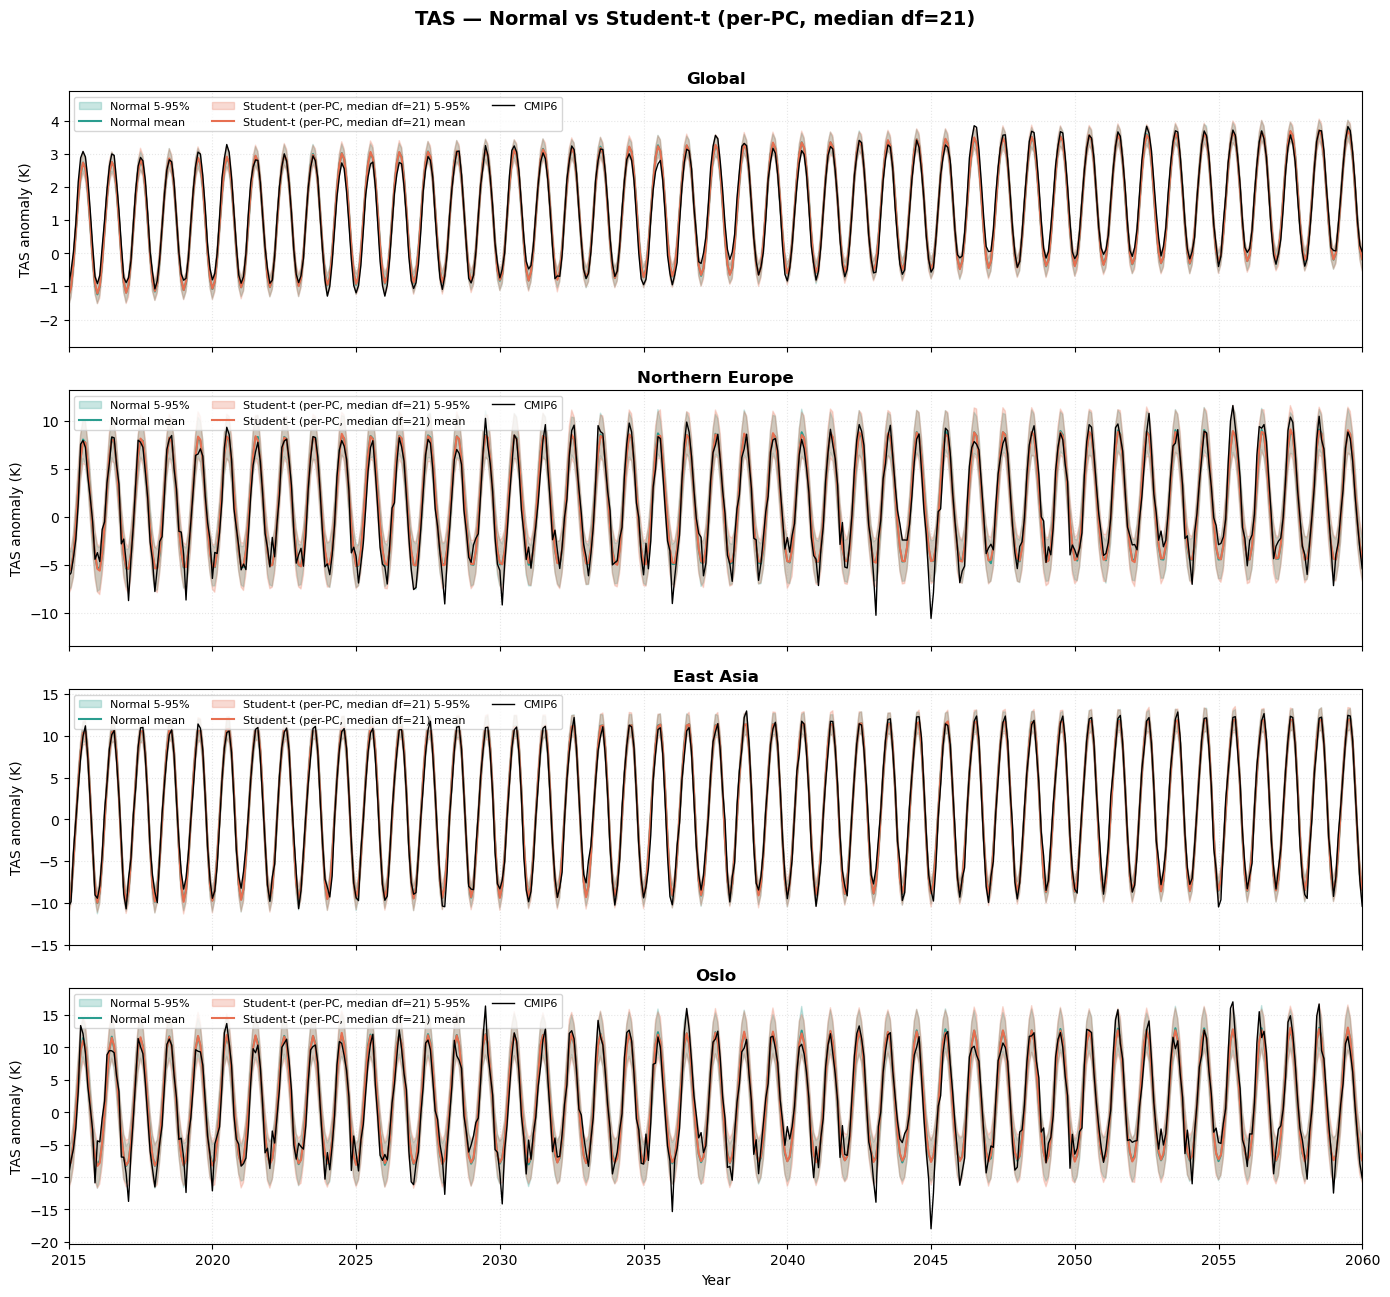

In [13]:
compare_locs = [
    ('global', 'Global'),
    ('regional:NEU', 'Northern Europe'),
    ('regional:EAS', 'East Asia'),
    (f"point:{cities['Oslo']['lat']},{cities['Oslo']['lon']}", 'Oslo'),
]

fig, axes = plt.subplots(len(compare_locs), 1, figsize=(14, 3.2 * len(compare_locs)), sharex=True)
if len(compare_locs) == 1:
    axes = [axes]

for ax, (loc, label) in zip(axes, compare_locs):
    data_n = ens_normal['tas'].timeseries[loc]
    data_t = ens_t['tas'].timeseries[loc]
    n_months = data_n.shape[1]
    years = START_YEAR + np.arange(n_months) / 12

    # Normal percentiles
    p5_n  = np.percentile(data_n, 5, axis=0)
    p95_n = np.percentile(data_n, 95, axis=0)
    mean_n = data_n.mean(axis=0)

    # Student-t percentiles
    p5_t  = np.percentile(data_t, 5, axis=0)
    p95_t = np.percentile(data_t, 95, axis=0)
    mean_t = data_t.mean(axis=0)

    ax.fill_between(years, p5_n,  p95_n,  color='#2A9D8F', alpha=0.25, label='Normal 5-95%')
    ax.plot(years, mean_n, color='#2A9D8F', lw=1.5, label='Normal mean')

    ax.fill_between(years, p5_t,  p95_t,  color='#E76F51', alpha=0.25, label=f'{t_label} 5-95%')
    ax.plot(years, mean_t, color='#E76F51', lw=1.5, label=f'{t_label} mean')

    # CMIP6 reference
    cmip6_ref = cmip6_timeseries.get(loc)
    if cmip6_ref is None:
        cmip6_ref = cmip6_point_data.get(loc)
    if cmip6_ref is not None:
        n_cmip = cmip6_ref.shape[-1] if cmip6_ref.values.ndim == 1 else cmip6_ref.shape[1]
        yrs_cmip = START_YEAR + np.arange(n_cmip) / 12
        if cmip6_ref.values.ndim == 2:
            ax.plot(yrs_cmip, cmip6_ref.mean(dim='ens'), 'k-', lw=1, label='CMIP6', zorder=10)
        else:
            ax.plot(yrs_cmip, cmip6_ref, 'k-', lw=1, label='CMIP6', zorder=10)

    ax.set_xlim([2015, 2060])
    ax.set_ylabel('TAS anomaly (K)')
    ax.set_title(label, fontweight='bold')
    ax.grid(True, alpha=0.3, ls=':')
    ax.legend(fontsize=8, loc='upper left', ncol=3)

axes[-1].set_xlabel('Year')
fig.suptitle(f'TAS — Normal vs {t_label}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'student_t_timeseries_tas.pdf'), bbox_inches='tight', dpi=200)
plt.show()

## 6. Tail behaviour: 1st/99th percentile difference

The Student-t should widen the extreme tails (1st/99th) relative to the normal, while the
5th/95th should be similar because both share the same covariance. Plot the ratio of
inter-percentile ranges.

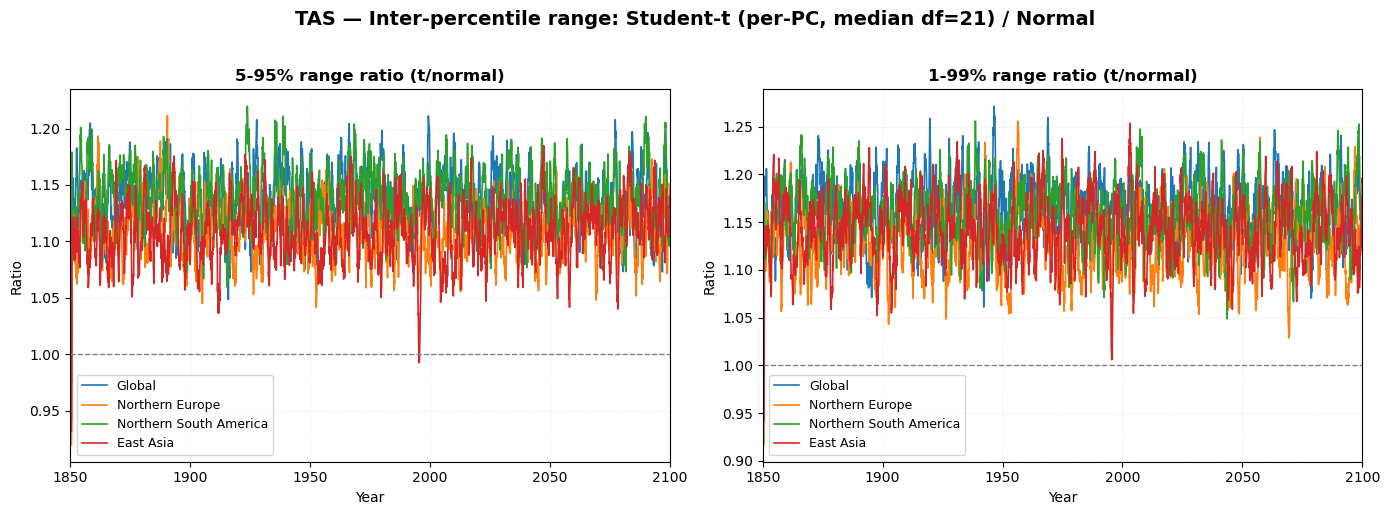

In [14]:
all_locs = ['global'] + [f'regional:{r}' for r in regions]
all_labels = ['Global'] + [region_names[r] for r in regions]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for loc, label in zip(all_locs, all_labels):
    dn = ens_normal['tas'].timeseries[loc]
    dt = ens_t['tas'].timeseries[loc]
    n_months = dn.shape[1]
    years = START_YEAR + np.arange(n_months) / 12

    # 5-95 range ratio
    range_n_90 = np.percentile(dn, 95, axis=0) - np.percentile(dn, 5, axis=0)
    range_t_90 = np.percentile(dt, 95, axis=0) - np.percentile(dt, 5, axis=0)
    ratio_90 = range_t_90 / np.maximum(range_n_90, 1e-12)

    # 1-99 range ratio
    range_n_98 = np.percentile(dn, 99, axis=0) - np.percentile(dn, 1, axis=0)
    range_t_98 = np.percentile(dt, 99, axis=0) - np.percentile(dt, 1, axis=0)
    ratio_98 = range_t_98 / np.maximum(range_n_98, 1e-12)

    # 12-month running mean to smooth
    k = np.ones(12) / 12
    axes[0].plot(years[6:-5], np.convolve(ratio_90, k, 'valid'), label=label, lw=1.2)
    axes[1].plot(years[6:-5], np.convolve(ratio_98, k, 'valid'), label=label, lw=1.2)

for ax, title in zip(axes, ['5-95% range ratio (t/normal)', '1-99% range ratio (t/normal)']):
    ax.axhline(1.0, color='grey', ls='--', lw=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Ratio')
    ax.set_xlim([START_YEAR, END_YEAR])
    ax.grid(True, alpha=0.3, ls=':')
    ax.legend(fontsize=9)

fig.suptitle(f'TAS — Inter-percentile range: {t_label} / Normal',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'student_t_tail_ratio_tas.pdf'), bbox_inches='tight', dpi=200)
plt.show()

## 7. Kurtosis comparison

Excess kurtosis of the de-trended residuals at each time step. A normal distribution has
excess kurtosis 0; Student-t should produce positive excess kurtosis.

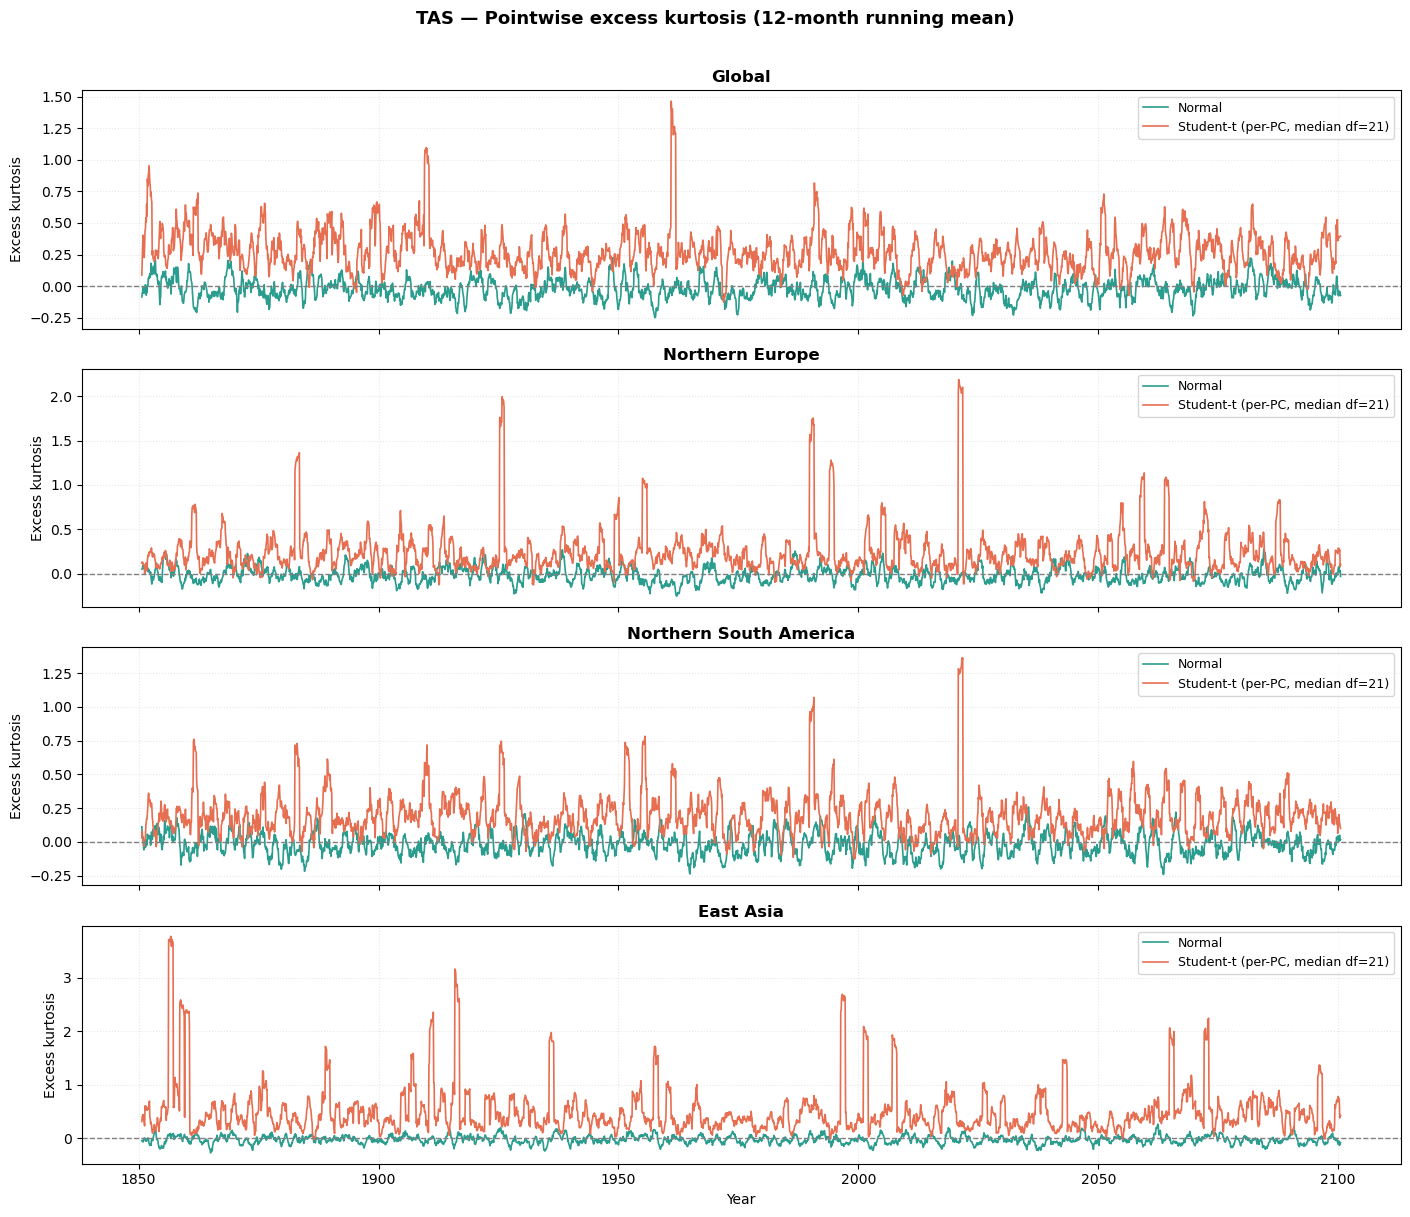

In [15]:
fig, axes = plt.subplots(len(all_locs), 1, figsize=(14, 3 * len(all_locs)), sharex=True)
if len(all_locs) == 1:
    axes = [axes]

for ax, (loc, label) in zip(axes, zip(all_locs, all_labels)):
    dn = ens_normal['tas'].timeseries[loc]
    dt = ens_t['tas'].timeseries[loc]
    n_months = dn.shape[1]
    years = START_YEAR + np.arange(n_months) / 12

    resid_n = dn - dn.mean(axis=0, keepdims=True)
    resid_t = dt - dt.mean(axis=0, keepdims=True)

    kurt_n = stats.kurtosis(resid_n, axis=0, fisher=True)
    kurt_t = stats.kurtosis(resid_t, axis=0, fisher=True)

    k = np.ones(12) / 12
    ax.plot(years[6:-5], np.convolve(kurt_n, k, 'valid'), color='#2A9D8F', lw=1.2, label='Normal')
    ax.plot(years[6:-5], np.convolve(kurt_t, k, 'valid'), color='#E76F51', lw=1.2, label=t_label)
    ax.axhline(0, color='grey', ls='--', lw=1)
    ax.set_ylabel('Excess kurtosis')
    ax.set_title(label, fontweight='bold')
    ax.grid(True, alpha=0.3, ls=':')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Year')
fig.suptitle(f'TAS — Pointwise excess kurtosis (12-month running mean)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'student_t_kurtosis_tas.pdf'), bbox_inches='tight', dpi=200)
plt.show()

## 8. Rank histograms — Normal vs Student-t

Rank the CMIP6 time series within each emulated ensemble. Columns: locations.
Top row: Normal. Bottom row: Student-t.

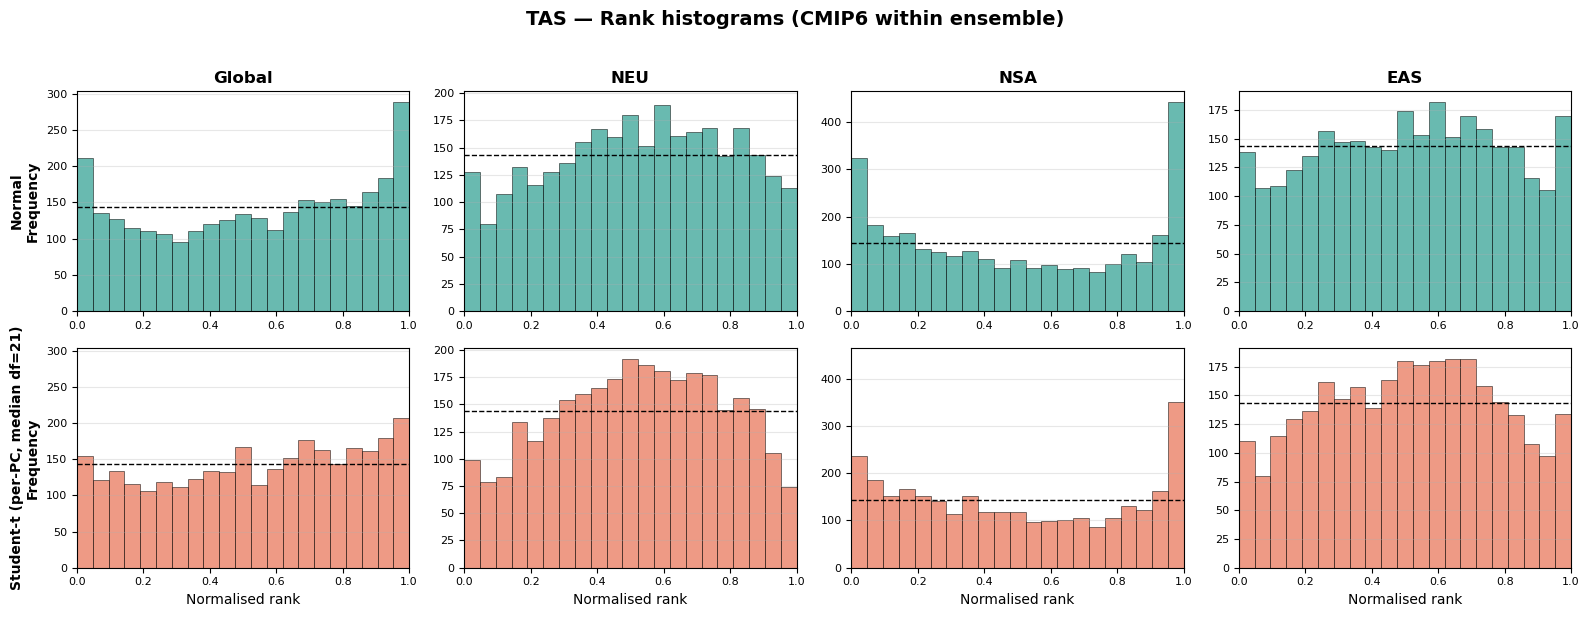

In [16]:
def calculate_ranks(emulated_data, cmip6_data):
    """Normalised ranks of CMIP6 within emulated ensemble."""
    n_real = emulated_data.shape[0]
    n_time = emulated_data.shape[1]
    vals = cmip6_data.values
    if vals.ndim == 2:
        subset = vals[:, -n_time:]
    else:
        subset = vals[-n_time:][None, :]
    ranks = []
    for e in range(subset.shape[0]):
        for t in range(subset.shape[1]):
            ranks.append(np.sum(emulated_data[:, t] < float(subset[e, t])) / n_real)
    return ranks


rank_locs = ['global', 'regional:NEU', 'regional:NSA', 'regional:EAS']
rank_labels = ['Global', 'NEU', 'NSA', 'EAS']
n_bins = 21

fig, axes = plt.subplots(2, len(rank_locs), figsize=(4 * len(rank_locs), 6), sharey='col')

for col, (loc, label) in enumerate(zip(rank_locs, rank_labels)):
    cmip6_ref = cmip6_timeseries[loc]

    for row, (ens, ens_label, color) in enumerate([
        (ens_normal, 'Normal', '#2A9D8F'),
        (ens_t,      t_label, '#E76F51'),
    ]):
        ax = axes[row, col]
        ranks = calculate_ranks(ens['tas'].timeseries[loc], cmip6_ref)
        counts, bins, _ = ax.hist(ranks, bins=n_bins, range=(0, 1),
                                  color=color, alpha=0.7, edgecolor='black', lw=0.5)
        expected = len(ranks) / n_bins
        ax.axhline(expected, color='black', ls='--', lw=1)
        if row == 0:
            ax.set_title(label, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{ens_label}\nFrequency', fontweight='bold')
        ax.set_xlim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(labelsize=8)
        if row == 1:
            ax.set_xlabel('Normalised rank')

fig.suptitle('TAS — Rank histograms (CMIP6 within ensemble)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'student_t_rank_histograms_tas.pdf'), bbox_inches='tight', dpi=200)
plt.show()

## 9. Rank histograms — point locations

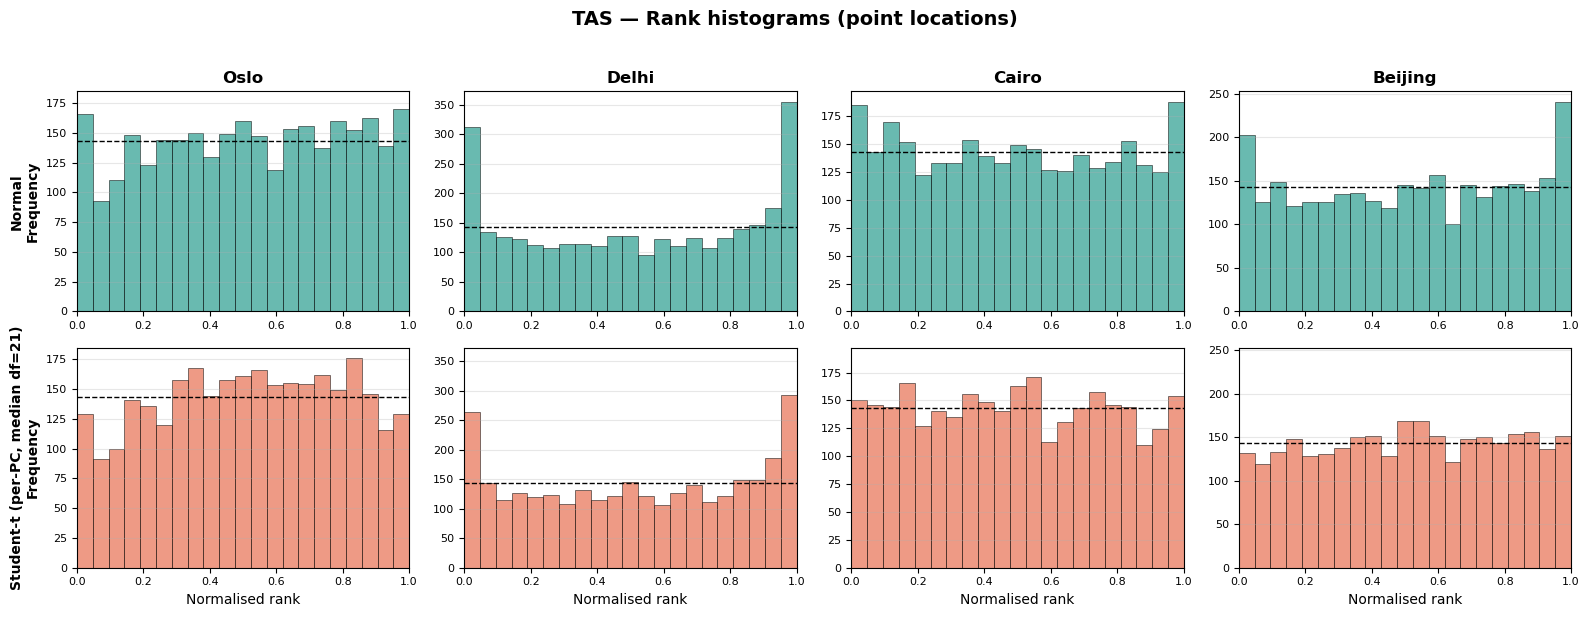

In [17]:
city_names = list(cities.keys())
point_keys = [f"point:{cities[c]['lat']},{cities[c]['lon']}" for c in city_names]

fig, axes = plt.subplots(2, len(city_names), figsize=(4 * len(city_names), 6), sharey="col")

for col, (key, city) in enumerate(zip(point_keys, city_names)):
    cmip6_ref = cmip6_point_data[key]

    for row, (ens, ens_label, color) in enumerate([
        (ens_normal, 'Normal', '#2A9D8F'),
        (ens_t,      t_label, '#E76F51'),
    ]):
        ax = axes[row, col]
        ranks = calculate_ranks(ens['tas'].timeseries[key], cmip6_ref)
        counts, _, _ = ax.hist(ranks, bins=n_bins, range=(0, 1),
                               color=color, alpha=0.7, edgecolor='black', lw=0.5)
        expected = len(ranks) / n_bins
        ax.axhline(expected, color='black', ls='--', lw=1)
        if row == 0:
            ax.set_title(city, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{ens_label}\nFrequency', fontweight='bold')
        ax.set_xlim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(labelsize=8)
        if row == 1:
            ax.set_xlabel('Normalised rank')

fig.suptitle('TAS — Rank histograms (point locations)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'student_t_rank_histograms_points_tas.pdf'), bbox_inches='tight', dpi=200)
plt.show()

## 10. Histogram of monthly residuals at a single location

Pool all (realization, time) residuals for a chosen location, compare the empirical
distribution of Normal vs Student-t against a fitted Gaussian.

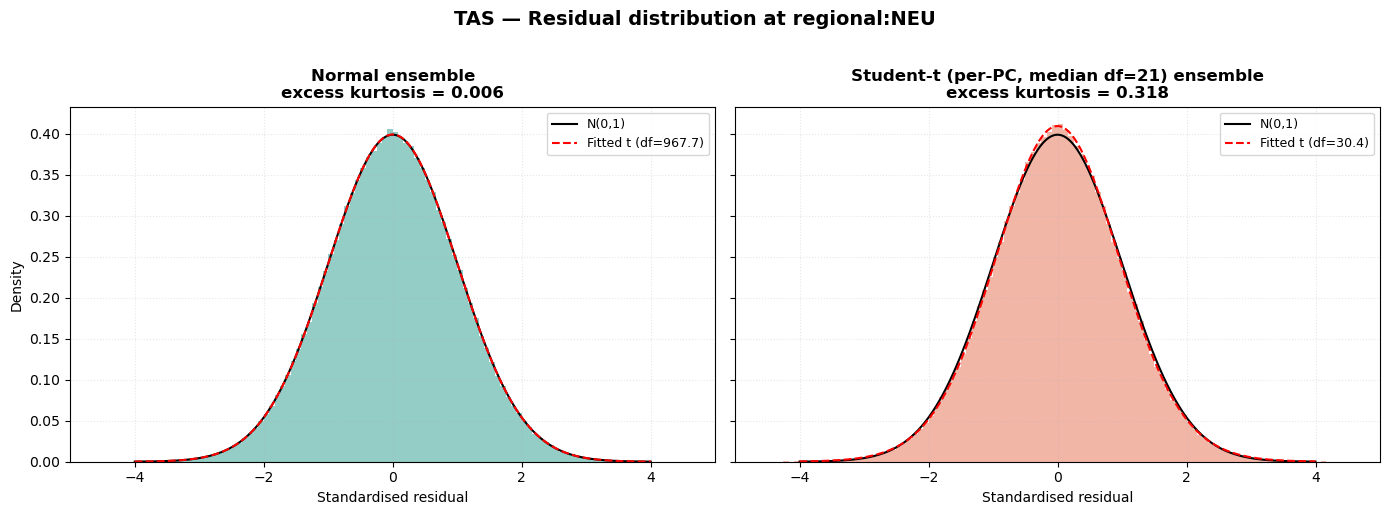

In [18]:
loc = 'regional:NEU'

dn = ens_normal['tas'].timeseries[loc]
dt = ens_t['tas'].timeseries[loc]

resid_n = (dn - dn.mean(axis=0, keepdims=True)).ravel()
resid_t = (dt - dt.mean(axis=0, keepdims=True)).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.linspace(-4, 4, 300)

for ax, resid, label, color in [
    (axes[0], resid_n, 'Normal ensemble', '#2A9D8F'),
    (axes[1], resid_t, f'{t_label} ensemble', '#E76F51'),
]:
    z = (resid - resid.mean()) / resid.std()
    ax.hist(z, bins=120, range=(-5, 5), density=True, color=color, alpha=0.5, edgecolor='none')

    ax.plot(x, stats.norm.pdf(x), 'k-', lw=1.5, label='N(0,1)')

    df_fit, loc_fit, scale_fit = stats.t.fit(z)
    ax.plot(x, stats.t.pdf(x, df_fit, loc_fit, scale_fit), '--', color='red', lw=1.5,
            label=f'Fitted t (df={df_fit:.1f})')

    ax.set_title(f'{label}\nexcess kurtosis = {stats.kurtosis(z):.3f}', fontweight='bold')
    ax.set_xlabel('Standardised residual')
    ax.set_xlim([-5, 5])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, ls=':')

axes[0].set_ylabel('Density')
fig.suptitle(f'TAS — Residual distribution at {loc}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'student_t_residual_histograms_tas.pdf'), bbox_inches='tight', dpi=200)
plt.show()

## 11. Summary statistics table

In [19]:
import pandas as pd

In [20]:
rows = []
for loc in all_locs:
    for tag, ens in [('Normal', ens_normal), (t_label, ens_t)]:
        ts = ens['tas'].timeseries.get(loc)
        if ts is None:
            continue
        resid = (ts - ts.mean(axis=0, keepdims=True)).ravel()
        rows.append({
            'location': loc,
            'ensemble': tag,
            'std': np.std(resid),
            'skew': stats.skew(resid),
            'excess_kurtosis': stats.kurtosis(resid),
        })

df_stats = pd.DataFrame(rows)
display(df_stats.style
        .format({'std': '{:.4f}', 'skew': '{:.3f}', 'excess_kurtosis': '{:.3f}'})
        .set_caption('Summary statistics of TAS ensemble residuals'))

,location,ensemble,std,skew,excess_kurtosis
0,global,Normal,0.1753,0.006,0.001
1,global,"Student-t (per-PC, median df=21)",0.1997,0.003,0.321
2,regional:NEU,Normal,1.3270,0.000,0.006
3,regional:NEU,"Student-t (per-PC, median df=21)",1.4758,0.008,0.318
4,regional:NSA,Normal,0.4101,0.000,0.006
5,regional:NSA,"Student-t (per-PC, median df=21)",0.4683,0.001,0.237
6,regional:EAS,Normal,0.7816,-0.002,-0.003
7,regional:EAS,"Student-t (per-PC, median df=21)",0.8747,0.002,0.676


In [21]:
# ======================================================================
# Combined analysis cell: train emulators, generate ensembles,
# and quantify Normal vs Student-t model differences
# ======================================================================

# 0. Setup and imports
# ----------------------------------------------------------------------
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from meteor import MeteorInterface, Cmip6MeteorDataGetter, geo_data_utils
import pandas as pd

print("Imports complete")

# Machine / paths (as in the investigation)
MACHINE = "ivan/mimi/victor"  # or your machine label
if MACHINE == "ivan/mimi/victor":
    cache_dir = Path("/scratch/johannlf")
else:
    from fys9429 import PROJECT_ROOT
    cache_dir = PROJECT_ROOT.joinpath("cache")

FIGURE_DIR = 'figures'
os.makedirs(FIGURE_DIR, exist_ok=True)
print(f"Cache dir: {cache_dir}")
print(f"Figure dir: {os.path.abspath(FIGURE_DIR)}")

# 1. Configuration
# ----------------------------------------------------------------------
MODEL = 'NorESM2-MM'
VARIABLES = ['tas']
N_REALIZATIONS = 300
SCENARIO = 'ssp245'
START_YEAR = 1850
END_YEAR = 2100

regions = ['NEU', 'NSA', 'EAS']
region_names = {
    'NEU': 'Northern Europe',
    'NSA': 'Northern South America',
    'EAS': 'East Asia'
}

cities = {
    'Oslo':   {'lat': 59.9, 'lon': 10.8},
    'Delhi':  {'lat': 28.6, 'lon': 77.2},
    'Cairo':  {'lat': 30.0, 'lon': 31.2},
    'Beijing':{'lat': 39.9, 'lon': 116.4},
}

timeseries = ['global']
timeseries += [f'regional:{r}' for r in regions]
timeseries += [f"point:{cities[c]['lat']},{cities[c]['lon']}" for c in cities.keys()]

print(f"Model: {MODEL}")
print(f"Variables: {VARIABLES}")
print(f"Spatial aggregations: {len(timeseries)}")
for ts in timeseries:
    print(f"  {ts}")

# 2. Load CMIP6 reference data (for rank histograms and time-series comparison)
# ----------------------------------------------------------------------
# Based on the notebook CMIP6-loading logic
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "historical", "ssp245", "ssp126", "ssp585"],
    flds=['tas'],
    dbe=['CMIP', 'CMIP', 'ScenarioMIP', 'ScenarioMIP', 'ScenarioMIP'],
    enable_cache=True
)

cmip6_data_raw = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], MODEL, monthly=True
)
picontrol_data = data_getter.make_meteor_training_data(
    "piControl", MODEL, monthly=True
)

cmip6_timeseries = {}
cmip6_point_data = {}

# Global
cmip6_global_abs = geo_data_utils.global_mean(cmip6_data_raw['tas'])
picontrol_global = geo_data_utils.global_mean(picontrol_data['tas'])
picontrol_baseline = picontrol_global.mean()
cmip6_timeseries['global'] = cmip6_global_abs - picontrol_baseline

# Regions
for region in regions:
    cmip6_reg_abs = geo_data_utils.regional_mean(cmip6_data_raw['tas'], region)
    picontrol_reg = geo_data_utils.regional_mean(picontrol_data['tas'], region)
    cmip6_timeseries[f'regional:{region}'] = cmip6_reg_abs - picontrol_reg.mean()

# Points
for city_name, coords in cities.items():
    key = f"point:{coords['lat']},{coords['lon']}"
    cmip6_pt = geo_data_utils.extract_point(
        cmip6_data_raw['tas'], coords['lat'], coords['lon']
    )
    picontrol_pt = geo_data_utils.extract_point(
        picontrol_data['tas'], coords['lat'], coords['lon']
    )
    cmip6_point_data[key] = cmip6_pt - picontrol_pt.mean()

print(f"CMIP6 TAS shape: {cmip6_data_raw['tas'].shape}")
print(f"Point locations loaded: {len(cmip6_point_data)}")

# 3. Train emulators: Normal vs Student-t
# ----------------------------------------------------------------------
# Normal emulator: standard MVN errors
emu_normal = MeteorInterface(model=MODEL, variables=VARIABLES, cache_dir=cache_dir)
emu_normal.train(verbose=True)
print("Normal emulator trained.\n")

# Student-t emulator: noise_pc_distribution='t', df via MLE
t_configs = {'tas': {'noise_pc_distribution': 't', 't_df': 'mle'}}
emu_t = MeteorInterface(model=MODEL, variables=VARIABLES, cache_dir=cache_dir)
emu_t.train(variable_configs=t_configs, verbose=True)
print("Student-t emulator trained.")

# Inspect VARX residuals from normal noise model (per-PC kurtosis and fitted t-df)
from scipy.stats import kurtosis as scipy_kurtosis, t as scipy_t

noise_model = emu_normal.noise_models['tas']
residuals = noise_model.varx_results.resid  # (n_obs, n_modes)
n_obs, n_modes = residuals.shape
print(f"VARX residuals shape: {residuals.shape}")

pc_kurtosis = scipy_kurtosis(residuals, axis=0, fisher=True)
pc_best_df = np.zeros(n_modes)
for j in range(n_modes):
    r = residuals[:, j]
    df_fit, _, _ = scipy_t.fit(r)
    pc_best_df[j] = df_fit

print(
    f"Excess kurtosis — mean: {pc_kurtosis.mean():.3f}, "
    f"max: {pc_kurtosis.max():.3f} (PC {pc_kurtosis.argmax()}), "
    f"min: {pc_kurtosis.min():.3f} (PC {pc_kurtosis.argmin()})"
)
print(
    f"MLE df — median: {np.median(pc_best_df):.1f}, "
    f"min: {pc_best_df.min():.1f} (PC {pc_best_df.argmin()}), "
    f"max: {pc_best_df.max():.1f} (PC {pc_best_df.argmax()})"
)

# 4. Generate ensembles (Normal and Student-t) with identical settings
# ----------------------------------------------------------------------
gen_kwargs = dict(
    scenario=SCENARIO,
    start_year=START_YEAR,
    end_year=END_YEAR,
    n_realizations=N_REALIZATIONS,
    timeseries=timeseries,
    verbose=True,
)

ens_normal = emu_normal.generate_ensemble_outputs(**gen_kwargs)
print(f"Normal ensemble: {N_REALIZATIONS} realisations\n")

ens_t = emu_t.generate_ensemble_outputs(**gen_kwargs)
print(f"Student-t ensemble: {N_REALIZATIONS} realisations")

# Per-PC fitted df for the Student-t noise model (from emu_t)
fitted_df_arr = emu_t.noise_models['tas']._fitted_df
med_df = np.median(fitted_df_arr)
t_label = f"Student-t (per-PC, median df={med_df:.0f})"

n_heavy = (fitted_df_arr < 15).sum()
print(f"\nPer-PC fitted df (median={med_df:.1f}):")
print(f"  {np.array2string(fitted_df_arr, precision=1, separator=', ')}")
print(f"  {n_heavy}/{len(fitted_df_arr)} PCs with df < 15")

# 5. Helper functions for quantitative comparison
# ----------------------------------------------------------------------
def calculate_ranks(emulated_data, cmip6_data):
    """
    Normalised ranks of CMIP6 within emulated ensemble.
    Mirrors the notebook's rank-histogram logic.
    <ref: index={3075983} firstWord={120} lastWord={170}/>
    """
    n_real = emulated_data.shape[0]
    n_time = emulated_data.shape[1]

    vals = cmip6_data.values
    if vals.ndim == 2:
        subset = vals[:, -n_time:]
    else:
        subset = vals[-n_time:][None, :]

    ranks = []
    for e in range(subset.shape[0]):
        for t in range(subset.shape[1]):
            ranks.append(
                np.sum(emulated_data[:, t] < float(subset[e, t])) / n_real
            )
    return np.array(ranks)


def get_residuals(ts):
    """
    Flattened residuals after removing ensemble mean at each time:
        residual = member - ensemble_mean(t)
    This matches the residual pooling used for histograms and tables.
    <ref: index={3075980} firstWord={120} lastWord={180}/>
    """
    return (ts - ts.mean(axis=0, keepdims=True)).ravel()


def residual_summary(ts):
    """
    Compute std, skew, and excess kurtosis of residuals for one location.
    Matches the "Summary statistics table" logic.
    <ref: index={3075984} firstWord={120} lastWord={190}/>
    """
    resid = get_residuals(ts)
    return dict(
        std=float(np.std(resid)),
        skew=float(stats.skew(resid)),
        excess_kurtosis=float(stats.kurtosis(resid)),
    )


def tail_range_ratios(dn, dt, p_low, p_high):
    """
    Time series of tail-width ratios:
        ratio = (t-range) / (normal-range),
    where range = percentile_high - percentile_low.
    Implements the same range-ratio idea as the tail plot.
    <ref: index={3075978} firstWord={1} lastWord={80}/>
    """
    range_n = np.percentile(dn, p_high, axis=0) - np.percentile(dn, p_low, axis=0)
    range_t = np.percentile(dt, p_high, axis=0) - np.percentile(dt, p_low, axis=0)
    return range_t / np.maximum(range_n, 1e-12)


def aggregate_tail_ratios(ens_normal, ens_t, loc):
    """
    For a given location, compute summary statistics of:
      - 5–95% range ratio
      - 1–99% range ratio
    over the whole time period.
    """
    dn = ens_normal['tas'].timeseries[loc]
    dt = ens_t['tas'].timeseries[loc]

    r90 = tail_range_ratios(dn, dt, 5, 95)
    r98 = tail_range_ratios(dn, dt, 1, 99)

    def summarise(r):
        return {
            'mean': float(np.mean(r)),
            'median': float(np.median(r)),
            'q10': float(np.quantile(r, 0.10)),
            'q90': float(np.quantile(r, 0.90)),
        }

    return {
        'ratio_5_95': summarise(r90),
        'ratio_1_99': summarise(r98),
    }


def time_kurtosis_stats(dn, dt):
    """
    Compare excess kurtosis of residuals per time step between
    normal and Student-t ensembles.
    Returns statistics of:
        diff = kurt_t - kurt_n
    where kurtosis is computed along the realization axis.
    <ref: index={3075978} firstWord={80} lastWord={160}/>
    """
    resid_n = dn - dn.mean(axis=0, keepdims=True)
    resid_t = dt - dt.mean(axis=0, keepdims=True)

    kurt_n = stats.kurtosis(resid_n, axis=0, fisher=True)
    kurt_t = stats.kurtosis(resid_t, axis=0, fisher=True)

    diff = kurt_t - kurt_n
    return dict(
        mean_diff=float(np.mean(diff)),
        median_diff=float(np.median(diff)),
        q10_diff=float(np.quantile(diff, 0.10)),
        q90_diff=float(np.quantile(diff, 0.90)),
    )


def rank_histogram_metrics(ranks, n_bins=21):
    """
    Diagnostics for how close a rank histogram is to uniform.
    Returns:
      - chi2: chi-square distance from uniform counts
      - var_counts: variance of histogram counts
    """
    counts, _ = np.histogram(ranks, bins=n_bins, range=(0.0, 1.0))
    total = counts.sum()
    expected = total / n_bins

    chi2 = float(((counts - expected) ** 2 / expected).sum())
    var_counts = float(np.var(counts))

    return dict(
        n_bins=n_bins,
        chi2=chi2,
        var_counts=var_counts,
    )


def ensemble_rank_diagnostics(
    ens_normal, ens_t,
    cmip6_timeseries, cmip6_point_data,
    rank_locs=('global', 'regional:NEU', 'regional:NSA', 'regional:EAS'),
    n_bins=21,
):
    """
    For each location and each ensemble, compute rank-histogram
    diagnostics (chi2, variance).
    Based on the rank-histogram plotting code.
    <ref: index={3075983} firstWord={80} lastWord={170}/>
    """
    rows = []
    for loc in rank_locs:
        cmip6_ref = cmip6_timeseries.get(loc)
        if cmip6_ref is None:
            cmip6_ref = cmip6_point_data.get(loc)
        if cmip6_ref is None:
            continue

        for tag, ens in [('Normal', ens_normal), (t_label, ens_t)]:
            ranks = calculate_ranks(ens['tas'].timeseries[loc], cmip6_ref)
            metrics = rank_histogram_metrics(ranks, n_bins=n_bins)
            rows.append({
                'location': loc,
                'ensemble': tag,
                **metrics
            })

    return pd.DataFrame(rows)


def single_location_residual_fit(ts):
    """
    Standardise pooled residuals and fit a Student-t distribution.
    Used to measure tail-heaviness at one location.
    Mirrors the residual histogram fitting logic.
    <ref: index={3075984} firstWord={1} lastWord={80}/>
    """
    resid = get_residuals(ts)
    z = (resid - resid.mean()) / resid.std()
    df_fit, loc_fit, scale_fit = stats.t.fit(z)
    return dict(
        df_fit=float(df_fit),
        excess_kurtosis=float(stats.kurtosis(z)),
    )


def quantify_model_differences(
    ens_normal,
    ens_t,
    cmip6_timeseries,
    cmip6_point_data,
    regions,
    region_names,
):
    """
    High-level comparison between Normal and Student-t METEOR emulators.

    Produces:
      - residual_stats: std/skew/kurtosis per location & ensemble
      - tail_stats: tail range ratio summaries (5–95%, 1–99%) per region/global
      - kurtosis_time_stats: time-local kurtosis difference summaries
      - rank_diag: rank histogram diagnostics vs CMIP6
      - residual_fit_example: t-fit at one example location (regional:NEU)
    """
    all_locs = ['global'] + [f'regional:{r}' for r in regions]
    all_labels = ['Global'] + [region_names[r] for r in regions]

    # 1) Residual statistics table (section 11 analogue)
    rows_resid = []
    for loc in all_locs:
        for tag, ens in [('Normal', ens_normal), (t_label, ens_t)]:
            ts = ens['tas'].timeseries.get(loc)
            if ts is None:
                continue
            stats_resid = residual_summary(ts)
            rows_resid.append({'location': loc, 'ensemble': tag, **stats_resid})
    residual_stats = pd.DataFrame(rows_resid)

    # 2) Tail-width ratio summaries (5–95%, 1–99%)
    rows_tail = []
    for loc, label in zip(all_locs, all_labels):
        dn = ens_normal['tas'].timeseries[loc]
        dt = ens_t['tas'].timeseries[loc]
        tstats = aggregate_tail_ratios(ens_normal, ens_t, loc)
        rows_tail.append({
            'location': loc,
            'label': label,
            **{f'5_95_{k}': v for k, v in tstats['ratio_5_95'].items()},
            **{f'1_99_{k}': v for k, v in tstats['ratio_1_99'].items()},
        })
    tail_stats = pd.DataFrame(rows_tail)

    # 3) Time-local kurtosis difference summaries
    rows_kurt = []
    for loc, label in zip(all_locs, all_labels):
        dn = ens_normal['tas'].timeseries[loc]
        dt = ens_t['tas'].timeseries[loc]
        kstats = time_kurtosis_stats(dn, dt)
        rows_kurt.append({'location': loc, 'label': label, **kstats})
    kurtosis_time_stats = pd.DataFrame(rows_kurt)

    # 4) Rank histogram diagnostics (global + 3 regions)
    rank_locs = ['global', 'regional:NEU', 'regional:NSA', 'regional:EAS']
    rank_diag = ensemble_rank_diagnostics(
        ens_normal, ens_t,
        cmip6_timeseries, cmip6_point_data,
        rank_locs=rank_locs,
        n_bins=21,
    )

    # 5) Example: residual t-fit at regional:NEU
    loc_example = 'regional:NEU'
    dn_ex = ens_normal['tas'].timeseries[loc_example]
    dt_ex = ens_t['tas'].timeseries[loc_example]
    residual_fit_example = {
        'Normal': single_location_residual_fit(dn_ex),
        t_label: single_location_residual_fit(dt_ex),
    }

    return dict(
        residual_stats=residual_stats,
        tail_stats=tail_stats,
        kurtosis_time_stats=kurtosis_time_stats,
        rank_diag=rank_diag,
        residual_fit_example=residual_fit_example,
    )

# 6. Run the quantitative comparison and show tables
# ----------------------------------------------------------------------
results = quantify_model_differences(
    ens_normal=ens_normal,
    ens_t=ens_t,
    cmip6_timeseries=cmip6_timeseries,
    cmip6_point_data=cmip6_point_data,
    regions=regions,
    region_names=region_names,
)

print("\n=== Residual statistics (std, skew, excess kurtosis) ===")
display(
    results['residual_stats']
    .sort_values(['location', 'ensemble'])
    .style.format({'std': '{:.4f}', 'skew': '{:.3f}', 'excess_kurtosis': '{:.3f}'})
)

print("\n=== Tail range ratios (Student-t / Normal, 5–95 and 1–99) ===")
display(results['tail_stats'].sort_values('location'))

print("\n=== Time-local excess kurtosis difference (Student-t - Normal) ===")
display(results['kurtosis_time_stats'].sort_values('location'))

print("\n=== Rank histogram diagnostics vs CMIP6 ===")
display(results['rank_diag'].sort_values(['location', 'ensemble']))

print("\n=== Example residual t-fit at regional:NEU ===")
print(results['residual_fit_example'])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports complete
Cache dir: /scratch/johannlf
Figure dir: /uio/kant/geo-geofag-u1/johannlf/FYS9429/investigations/monthly_output/figures
Model: NorESM2-MM
Variables: ['tas']
Spatial aggregations: 8
  global
  regional:NEU
  regional:NSA
  regional:EAS
  point:59.9,10.8
  point:28.6,77.2
  point:30.0,31.2
  point:39.9,116.4
CMIP6 TAS shape: (1, 3012, 192, 288)
Point locations loaded: 4
Training METEOR emulator for NorESM2-MM
Variables: tas

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-NorESM2-MM-aer', found 'cmip6-NorESM2-MM-aer-tas'
🔧 Preparing pattern scaling training data for NorESM2-MM...
   ✅ Training data prepared for experiments:  ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 351 emission records
   ✅ Config: 1750-2100, emissions sta

,location,ensemble,std,skew,excess_kurtosis
0,global,Normal,0.1750,-0.002,-0.002
1,global,"Student-t (per-PC, median df=21)",0.1998,0.002,0.389
6,regional:EAS,Normal,0.7815,-0.001,0.004
7,regional:EAS,"Student-t (per-PC, median df=21)",0.8751,0.069,2.755
2,regional:NEU,Normal,1.3262,-0.003,0.002
3,regional:NEU,"Student-t (per-PC, median df=21)",1.4776,0.008,0.295
4,regional:NSA,Normal,0.4094,0.000,0.011
5,regional:NSA,"Student-t (per-PC, median df=21)",0.4682,-0.001,0.222



=== Tail range ratios (Student-t / Normal, 5–95 and 1–99) ===


,location,label,5_95_mean,5_95_median,5_95_q10,5_95_q90,1_99_mean,1_99_median,1_99_q10,1_99_q90
0,global,Global,1.137851,1.136681,1.028867,1.249308,1.167050,1.164180,1.031299,1.315048
3,regional:EAS,East Asia,1.111008,1.108806,1.011409,1.215825,1.142768,1.136700,1.009808,1.283376
1,regional:NEU,Northern Europe,1.111180,1.109531,1.013484,1.214770,1.132824,1.127097,1.001564,1.268222
2,regional:NSA,Northern South America,1.141225,1.139360,1.034467,1.252881,1.160362,1.154719,1.026282,1.305296



=== Time-local excess kurtosis difference (Student-t - Normal) ===


,location,label,mean_diff,median_diff,q10_diff,q90_diff
0,global,Global,NaN,NaN,NaN,NaN
3,regional:EAS,East Asia,NaN,NaN,NaN,NaN
1,regional:NEU,Northern Europe,NaN,NaN,NaN,NaN
2,regional:NSA,Northern South America,NaN,NaN,NaN,NaN



=== Rank histogram diagnostics vs CMIP6 ===


,location,ensemble,n_bins,chi2,var_counts
0,global,Normal,21,252.914343,1727.387755
1,global,"Student-t (per-PC, median df=21)",21,82.920319,566.340136
6,regional:EAS,Normal,21,76.464143,522.244898
7,regional:EAS,"Student-t (per-PC, median df=21)",21,136.452191,931.959184
2,regional:NEU,Normal,21,94.005976,642.054422
3,regional:NEU,"Student-t (per-PC, median df=21)",21,212.615538,1452.149660
4,regional:NSA,Normal,21,957.223108,6537.768707
5,regional:NSA,"Student-t (per-PC, median df=21)",21,487.428287,3329.102041



=== Example residual t-fit at regional:NEU ===
{'Normal': {'df_fit': 2467.7680968117893, 'excess_kurtosis': 0.0024183116089440126}, 'Student-t (per-PC, median df=21)': {'df_fit': 28.53141870230114, 'excess_kurtosis': 0.2951364508547698}}


In [22]:
from regionmask.defined_regions import ar6
ar6_region_abbrevs = ar6.all.abbrevs
ar6_region_names = ar6.all.names

In [23]:


from meteor import MeteorInterface, Cmip6MeteorDataGetter, geo_data_utils
import pandas as pd

print("Imports complete")

# 1. Configuration
# ----------------------------------------------------------------------
MACHINE = "ivan/mimi/victor"   # adjust if needed

if MACHINE == "ivan/mimi/victor":
    cache_dir = Path("/scratch/johannlf")
else:
    from fys9429 import PROJECT_ROOT
    cache_dir = PROJECT_ROOT.joinpath("cache")

FIGURE_DIR = 'figures'
os.makedirs(FIGURE_DIR, exist_ok=True)
print(f"Cache dir: {cache_dir}")
print(f"Figure dir: {os.path.abspath(FIGURE_DIR)}")

MODEL = 'NorESM2-MM'
VARIABLES = ['tas']
N_REALIZATIONS = 300
SCENARIO = 'ssp245'
START_YEAR = 1850
END_YEAR = 2100

regions = ar6_region_abbrevs
region_names = {abbr: name for abbr, name in zip(ar6_region_abbrevs, ar6_region_names)}

timeseries = ['global']
timeseries += [f'regional:{r}' for r in regions]

print(f"Model: {MODEL}")
print(f"Variables: {VARIABLES}")
print(f"Spatial aggregations: {len(timeseries)}")
for ts in timeseries:
    print(" ", ts)

# 2. Load CMIP6 "training data" (truth for benchmarking)
# ----------------------------------------------------------------------
# As in the notebook: CMIP6 composite + piControl baseline -> anomalies
# <ref: index={3075974} firstWord={60} lastWord={140}/>
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "historical", "ssp245", "ssp126", "ssp585"],
    flds=['tas'],
    dbe=['CMIP', 'CMIP', 'ScenarioMIP', 'ScenarioMIP', 'ScenarioMIP'],
    enable_cache=True,
)

cmip6_data_raw = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], MODEL, monthly=True
)
picontrol_data = data_getter.make_meteor_training_data(
    "piControl", MODEL, monthly=True
)

cmip6_timeseries = {}
cmip6_point_data = {}

# Global
cmip6_global_abs = geo_data_utils.global_mean(cmip6_data_raw['tas'])
picontrol_global = geo_data_utils.global_mean(picontrol_data['tas'])
picontrol_baseline = picontrol_global.mean()
cmip6_timeseries['global'] = cmip6_global_abs - picontrol_baseline

# Regions
for region in regions:
    cmip6_reg_abs = geo_data_utils.regional_mean(cmip6_data_raw['tas'], region)
    picontrol_reg = geo_data_utils.regional_mean(picontrol_data['tas'], region)
    cmip6_timeseries[f'regional:{region}'] = cmip6_reg_abs - picontrol_reg.mean()

print(f"CMIP6 TAS shape: {cmip6_data_raw['tas'].shape}")
print(f"Point locations loaded: {len(cmip6_point_data)}")

# 3. Train emulators: Normal vs Student-t
# ----------------------------------------------------------------------
# Normal emulator (MVN errors)
emu_normal = MeteorInterface(model=MODEL, variables=VARIABLES, cache_dir=cache_dir)
emu_normal.train(verbose=True)
print("Normal emulator trained.\n")

t_configs = {'tas': {'noise_pc_distribution': 't', 't_df': 'mle'}}
emu_t = MeteorInterface(model=MODEL, variables=VARIABLES, cache_dir=cache_dir)
emu_t.train(variable_configs=t_configs, verbose=True)
print("Student-t emulator trained.\n")

# Inspect VARX residuals and per-PC Student-t df from normal noise model
from scipy.stats import kurtosis as scipy_kurtosis, t as scipy_t

noise_model = emu_normal.noise_models['tas']
residuals = noise_model.varx_results.resid   # (n_obs, n_modes)
n_obs, n_modes = residuals.shape
print(f"VARX residuals shape: {residuals.shape}")

pc_kurtosis = scipy_kurtosis(residuals, axis=0, fisher=True)
pc_best_df = np.zeros(n_modes)
for j in range(n_modes):
    r = residuals[:, j]
    df_fit, _, _ = scipy_t.fit(r)
    pc_best_df[j] = df_fit

print(
    f"Excess kurtosis — mean: {pc_kurtosis.mean():.3f}, "
    f"max: {pc_kurtosis.max():.3f} (PC {pc_kurtosis.argmax()}), "
    f"min: {pc_kurtosis.min():.3f} (PC {pc_kurtosis.argmin()})"
)
print(
    f"MLE df — median: {np.median(pc_best_df):.1f}, "
    f"min: {pc_best_df.min():.1f} (PC {pc_best_df.argmin()}), "
    f"max: {pc_best_df.max():.1f} (PC {pc_best_df.argmax()})"
)
n_heavy = (pc_best_df < 15).sum()
print(f"{n_heavy}/{n_modes} PCs with fitted df < 15\n")

# 4. Generate ensembles (same settings for Normal and Student-t)
# ----------------------------------------------------------------------
# <ref: index={3075981} firstWord={120} lastWord={210}/>
gen_kwargs = dict(
    scenario=SCENARIO,
    start_year=START_YEAR,
    end_year=END_YEAR,
    n_realizations=N_REALIZATIONS,
    timeseries=timeseries,
    verbose=True,
)

ens_normal = emu_normal.generate_ensemble_outputs(**gen_kwargs)
print(f"Normal ensemble: {N_REALIZATIONS} realisations\n")

ens_t = emu_t.generate_ensemble_outputs(**gen_kwargs)
print(f"Student-t ensemble: {N_REALIZATIONS} realisations")

# Per-PC MLE df from Student-t noise model
fitted_df_arr = emu_t.noise_models['tas']._fitted_df
med_df = np.median(fitted_df_arr)
t_label = f"Student-t (per-PC, median df={med_df:.0f})"
n_heavy_t = (fitted_df_arr < 15).sum()
print(f"\nPer-PC fitted df (median={med_df:.1f}):")
print(f" {np.array2string(fitted_df_arr, precision=1, separator=', ')}")
print(f" {n_heavy_t}/{len(fitted_df_arr)} PCs with df < 15")

# 5. Helper functions: differences + benchmarking vs CMIP6
# ----------------------------------------------------------------------
def calculate_ranks(emulated_data, cmip6_data):
    """
    Normalised ranks of CMIP6 within emulated ensemble.
    Notebook rank-histogram logic. <ref: index={3075983} firstWord={120} lastWord={190}/>
    """
    n_real = emulated_data.shape[0]
    n_time = emulated_data.shape[1]

    vals = cmip6_data.values
    if vals.ndim == 2:
        subset = vals[:, -n_time:]
    else:
        subset = vals[-n_time:][None, :]

    ranks = []
    for e in range(subset.shape[0]):
        for t in range(subset.shape[1]):
            ranks.append(
                np.sum(emulated_data[:, t] < float(subset[e, t])) / n_real
            )
    return np.array(ranks)


def get_residuals(ts):
    """
    Flatten residuals after removing ensemble mean at each time:
        residual = member - ensemble_mean(t)
    Used for histogram + stats table. <ref: index={3075984} firstWord={160} lastWord={220}/>
    """
    return (ts - ts.mean(axis=0, keepdims=True)).ravel()


def residual_summary(ts):
    """
    std, skew, excess kurtosis of ensemble residuals at one location.
    """
    resid = get_residuals(ts)
    return dict(
        std=float(np.std(resid)),
        skew=float(stats.skew(resid)),
        excess_kurtosis=float(stats.kurtosis(resid)),
    )


def tail_range_ratios(dn, dt, p_low, p_high):
    """
    Time series of tail-width ratios:
        ratio = (t-range) / (normal-range),
    where range = percentile_high - percentile_low.
    <ref: index={3075978} firstWord={1} lastWord={80}/>
    """
    range_n = np.percentile(dn, p_high, axis=0) - np.percentile(dn, p_low, axis=0)
    range_t = np.percentile(dt, p_high, axis=0) - np.percentile(dt, p_low, axis=0)
    return range_t / np.maximum(range_n, 1e-12)


def time_kurtosis_stats(dn, dt):
    """
    Time-local excess kurtosis difference:
        diff = kurt_t - kurt_n (per month), aggregated.
    """
    resid_n = dn - dn.mean(axis=0, keepdims=True)
    resid_t = dt - dt.mean(axis=0, keepdims=True)

    kurt_n = stats.kurtosis(resid_n, axis=0, fisher=True)
    kurt_t = stats.kurtosis(resid_t, axis=0, fisher=True)

    diff = kurt_t - kurt_n
    return dict(
        mean_diff=float(np.mean(diff)),
        median_diff=float(np.median(diff)),
        q10_diff=float(np.quantile(diff, 0.10)),
        q90_diff=float(np.quantile(diff, 0.90)),
    )


def rank_histogram_metrics(ranks, n_bins=21):
    """
    Diagnostics of how close rank histogram is to uniform.
    """
    counts, _ = np.histogram(ranks, bins=n_bins, range=(0.0, 1.0))
    total = counts.sum()
    expected = total / n_bins
    chi2 = float(((counts - expected) ** 2 / expected).sum())
    var_counts = float(np.var(counts))
    return dict(
        n_bins=n_bins,
        chi2=chi2,
        var_counts=var_counts,
    )


def coverage_metrics(ens_ts, cmip_ts):
    """
    Benchmark against CMIP6:
      - fraction of CMIP6 in 5–95% band
      - fraction in 1–99% band
      - RMSE of ensemble mean vs CMIP6
    Uses overlapping period implicitly (same monthly grid here).
    """
    # emu ensemble: (n_real, n_time)
    n_real, n_time = ens_ts.shape
    # CMIP6: DataArray or ndarray
    vals = cmip_ts.values
    if vals.ndim == 2:
        # ensemble dimension in CMIP6; average over it
        cmip_series = vals.mean(axis=0)[-n_time:]
    else:
        cmip_series = vals[-n_time:]

    p5 = np.percentile(ens_ts, 5, axis=0)
    p95 = np.percentile(ens_ts, 95, axis=0)
    p1 = np.percentile(ens_ts, 1, axis=0)
    p99 = np.percentile(ens_ts, 99, axis=0)
    mean_ens = ens_ts.mean(axis=0)

    in_5_95 = np.logical_and(cmip_series >= p5, cmip_series <= p95)
    in_1_99 = np.logical_and(cmip_series >= p1, cmip_series <= p99)

    cov_5_95 = float(in_5_95.mean())
    cov_1_99 = float(in_1_99.mean())
    rmse = float(np.sqrt(np.mean((mean_ens - cmip_series) ** 2)))

    return dict(
        coverage_5_95=cov_5_95,
        coverage_1_99=cov_1_99,
        rmse_mean=rmse,
    )


def ensemble_rank_diagnostics(
    ens_normal, ens_t,
    cmip6_timeseries, cmip6_point_data,
    rank_locs=('global', 'regional:NEU', 'regional:NSA', 'regional:EAS'),
    n_bins=21,
):
    """
    Rank-histogram diagnostics vs CMIP6 ("training" truth).
    <ref: index={3075980} firstWord={1} lastWord={80}/>
    """
    rows = []
    for loc in rank_locs:
        cmip6_ref = cmip6_timeseries.get(loc)
        if cmip6_ref is None:
            cmip6_ref = cmip6_point_data.get(loc)
        if cmip6_ref is None:
            continue

        for tag, ens in [('Normal', ens_normal), (t_label, ens_t)]:
            ranks = calculate_ranks(ens['tas'].timeseries[loc], cmip6_ref)
            metrics = rank_histogram_metrics(ranks, n_bins=n_bins)
            rows.append({
                'location': loc,
                'ensemble': tag,
                **metrics,
            })
    return pd.DataFrame(rows)


def single_location_residual_fit(ts):
    """
    Standardised pooled residuals + fitted Student-t df
    for a single location, used as a local tail diagnostic.
    <ref: index={3075984} firstWord={1} lastWord={80}/>
    """
    resid = get_residuals(ts)
    z = (resid - resid.mean()) / resid.std()
    df_fit, loc_fit, scale_fit = stats.t.fit(z)
    return dict(
        df_fit=float(df_fit),
        excess_kurtosis=float(stats.kurtosis(z)),
    )


def quantify_model_differences_and_benchmark(
    ens_normal,
    ens_t,
    cmip6_timeseries,
    cmip6_point_data,
    regions,
    region_names,
):
    """
    High-level summary:
      (A) Differences between Normal and Student-t ensembles
      (B) Benchmark of each emulator against CMIP6 "training data"
    """
    all_locs = ['global'] + [f'regional:{r}' for r in regions]
    all_labels = ['Global'] + [region_names[r] for r in regions]

    # --- (A1) Residual statistics (spread & shape, ensemble-only) ---
    rows_resid = []
    for loc in all_locs:
        for tag, ens in [('Normal', ens_normal), (t_label, ens_t)]:
            ts = ens['tas'].timeseries.get(loc)
            if ts is None:
                continue
            stats_resid = residual_summary(ts)
            rows_resid.append({'location': loc, 'ensemble': tag, **stats_resid})
    residual_stats = pd.DataFrame(rows_resid)

    # --- (A2) Tail-width ratio summaries (t / normal) ---
    rows_tail = []
    for loc, label in zip(all_locs, all_labels):
        dn = ens_normal['tas'].timeseries[loc]
        dt = ens_t['tas'].timeseries[loc]
        r90 = tail_range_ratios(dn, dt, 5, 95)
        r98 = tail_range_ratios(dn, dt, 1, 99)

        def summarise(r):
            return {
                'mean': float(np.mean(r)),
                'median': float(np.median(r)),
                'q10': float(np.quantile(r, 0.10)),
                'q90': float(np.quantile(r, 0.90)),
            }

        rows_tail.append({
            'location': loc,
            'label': label,
            **{f'5_95_{k}': v for k, v in summarise(r90).items()},
            **{f'1_99_{k}': v for k, v in summarise(r98).items()},
        })
    tail_stats = pd.DataFrame(rows_tail)

    # --- (A3) Time-local kurtosis difference (t - normal) ---
    rows_kurt = []
    for loc, label in zip(all_locs, all_labels):
        dn = ens_normal['tas'].timeseries[loc]
        dt = ens_t['tas'].timeseries[loc]
        kstats = time_kurtosis_stats(dn, dt)
        rows_kurt.append({'location': loc, 'label': label, **kstats})
    kurtosis_time_stats = pd.DataFrame(rows_kurt)

    # --- (B1) Rank-histogram diagnostics vs CMIP6 (training data) ---
    rank_locs = ['global', 'regional:NEU', 'regional:NSA', 'regional:EAS']
    rank_diag = ensemble_rank_diagnostics(
        ens_normal, ens_t,
        cmip6_timeseries, cmip6_point_data,
        rank_locs=rank_locs,
        n_bins=21,
    )

    # --- (B2) Coverage & RMSE vs CMIP6 for each ensemble ---
    rows_bench = []
    for loc, label in zip(all_locs, all_labels):
        cmip6_ref = cmip6_timeseries.get(loc)
        if cmip6_ref is None:
            continue
        for tag, ens in [('Normal', ens_normal), (t_label, ens_t)]:
            ts = ens['tas'].timeseries[loc]
            cov = coverage_metrics(ts, cmip6_ref)
            rows_bench.append({
                'location': loc,
                'label': label,
                'ensemble': tag,
                **cov,
            })
    coverage_benchmark = pd.DataFrame(rows_bench)

    # --- (B3) Example: residual distribution fit at regional:NEU for both ---
    loc_example = 'regional:NEU'
    dn_ex = ens_normal['tas'].timeseries[loc_example]
    dt_ex = ens_t['tas'].timeseries[loc_example]
    residual_fit_example = {
        'Normal': single_location_residual_fit(dn_ex),
        t_label: single_location_residual_fit(dt_ex),
    }

    return dict(
        residual_stats=residual_stats,
        tail_stats=tail_stats,
        kurtosis_time_stats=kurtosis_time_stats,
        rank_diag=rank_diag,
        coverage_benchmark=coverage_benchmark,
        residual_fit_example=residual_fit_example,
    )

# 6. Run comparison + benchmarking, display tables
# ----------------------------------------------------------------------
results = quantify_model_differences_and_benchmark(
    ens_normal=ens_normal,
    ens_t=ens_t,
    cmip6_timeseries=cmip6_timeseries,
    cmip6_point_data=cmip6_point_data,
    regions=regions,
    region_names=region_names,
)

print("\n=== (A1) Residual statistics (std, skew, excess kurtosis) ===")
display(
    results['residual_stats']
    .sort_values(['location', 'ensemble'])
    .style.format({'std': '{:.4f}', 'skew': '{:.3f}', 'excess_kurtosis': '{:.3f}'})
    .set_caption('Summary statistics of TAS ensemble residuals')
)

print("\n=== (A2) Tail-width ratios: Student-t / Normal (5–95 and 1–99) ===")
display(results['tail_stats'].sort_values('location'))

print("\n=== (A3) Time-local excess kurtosis difference (Student-t - Normal) ===")
display(results['kurtosis_time_stats'].sort_values('location'))

print("\n=== (B1) Rank-histogram diagnostics vs CMIP6 (training data) ===")
display(results['rank_diag'].sort_values(['location', 'ensemble']))

print("\n=== (B2) Coverage + RMSE vs CMIP6 (training data) ===")
display(
    results['coverage_benchmark']
    .sort_values(['location', 'ensemble'])
    .style.format({'coverage_5_95': '{:.3f}', 'coverage_1_99': '{:.3f}', 'rmse_mean': '{:.3f}'})
    .set_caption('Coverage of CMIP6 within ensemble bands and RMSE of ensemble mean')
)

print("\n=== (B3) Example residual t-fit at regional:NEU ===")
print(results['residual_fit_example'])


Imports complete
Cache dir: /scratch/johannlf
Figure dir: /uio/kant/geo-geofag-u1/johannlf/FYS9429/investigations/monthly_output/figures
Model: NorESM2-MM
Variables: ['tas']
Spatial aggregations: 59
  global
  regional:GIC
  regional:NWN
  regional:NEN
  regional:WNA
  regional:CNA
  regional:ENA
  regional:NCA
  regional:SCA
  regional:CAR
  regional:NWS
  regional:NSA
  regional:NES
  regional:SAM
  regional:SWS
  regional:SES
  regional:SSA
  regional:NEU
  regional:WCE
  regional:EEU
  regional:MED
  regional:SAH
  regional:WAF
  regional:CAF
  regional:NEAF
  regional:SEAF
  regional:WSAF
  regional:ESAF
  regional:MDG
  regional:RAR
  regional:WSB
  regional:ESB
  regional:RFE
  regional:WCA
  regional:ECA
  regional:TIB
  regional:EAS
  regional:ARP
  regional:SAS
  regional:SEA
  regional:NAU
  regional:CAU
  regional:EAU
  regional:SAU
  regional:NZ
  regional:EAN
  regional:WAN
  regional:ARO
  regional:NPO
  regional:EPO
  regional:SPO
  regional:NAO
  regional:EAO
  regiona

,location,ensemble,std,skew,excess_kurtosis
0,global,Normal,0.1753,0.002,0.002
1,global,"Student-t (per-PC, median df=21)",0.1997,0.004,0.296
94,regional:ARO,Normal,2.0483,-0.000,0.007
95,regional:ARO,"Student-t (per-PC, median df=21)",2.4852,0.015,2.519
74,regional:ARP,Normal,0.5965,-0.001,0.004
75,regional:ARP,"Student-t (per-PC, median df=21)",0.6467,-0.002,0.127
108,regional:ARS,Normal,0.2846,0.004,0.004
109,regional:ARS,"Student-t (per-PC, median df=21)",0.3141,0.005,0.121
110,regional:BOB,Normal,0.2618,0.001,0.005
111,regional:BOB,"Student-t (per-PC, median df=21)",0.2919,0.003,0.113



=== (A2) Tail-width ratios: Student-t / Normal (5–95 and 1–99) ===


,location,label,5_95_mean,5_95_median,5_95_q10,5_95_q90,1_99_mean,1_99_median,1_99_q10,1_99_q90
0,global,Global,1.134432,1.134622,1.031778,1.239477,1.161575,1.159544,1.028267,1.303199
47,regional:ARO,Arctic-Ocean,1.173693,1.171323,1.056318,1.300997,1.321571,1.311755,1.139960,1.521488
37,regional:ARP,Arabian-Peninsula,1.084727,1.081407,0.987345,1.188025,1.093777,1.086584,0.974302,1.222942
54,regional:ARS,Arabian-Sea,1.103791,1.100502,1.001969,1.210397,1.112574,1.110510,0.985955,1.237632
55,regional:BOB,Bay-of-Bengal,1.114542,1.111693,1.014629,1.221377,1.123763,1.118542,0.999660,1.257869
23,regional:CAF,Central-Africa,1.127795,1.125152,1.025615,1.234205,1.149007,1.146747,1.019998,1.286361
9,regional:CAR,Caribbean,1.080921,1.078641,0.985979,1.183871,1.092848,1.089769,0.966298,1.225363
41,regional:CAU,C.Australia,1.075577,1.074140,0.975739,1.176825,1.078848,1.074123,0.955895,1.201130
5,regional:CNA,C.North-America,1.104560,1.101979,1.003519,1.211764,1.118264,1.113193,0.994168,1.253897
45,regional:EAN,E.Antarctica,1.048413,1.046548,0.953142,1.148876,1.057082,1.054795,0.938941,1.181225



=== (A3) Time-local excess kurtosis difference (Student-t - Normal) ===


...


=== (B1) Rank-histogram diagnostics vs CMIP6 (training data) ===


,location,ensemble,n_bins,chi2,var_counts
0,global,Normal,21,255.605578,1745.768707
1,global,"Student-t (per-PC, median df=21)",21,99.458167,679.292517
6,regional:EAS,Normal,21,65.350598,446.340136
7,regional:EAS,"Student-t (per-PC, median df=21)",21,134.290837,917.197279
2,regional:NEU,Normal,21,92.262948,630.149660
3,regional:NEU,"Student-t (per-PC, median df=21)",21,201.990040,1379.578231
4,regional:NSA,Normal,21,995.723108,6800.721088
5,regional:NSA,"Student-t (per-PC, median df=21)",21,483.119522,3299.673469



=== (B2) Coverage + RMSE vs CMIP6 (training data) ===


,location,label,ensemble,coverage_5_95,coverage_1_99,rmse_mean
0,global,Global,Normal,0.826,0.930,0.211
1,global,Global,"Student-t (per-PC, median df=21)",0.872,0.959,0.211
94,regional:ARO,Arctic-Ocean,Normal,0.900,0.974,2.026
95,regional:ARO,Arctic-Ocean,"Student-t (per-PC, median df=21)",0.942,0.994,2.032
74,regional:ARP,Arabian-Peninsula,Normal,0.801,0.907,0.779
75,regional:ARP,Arabian-Peninsula,"Student-t (per-PC, median df=21)",0.832,0.929,0.780
108,regional:ARS,Arabian-Sea,Normal,0.708,0.858,0.441
109,regional:ARS,Arabian-Sea,"Student-t (per-PC, median df=21)",0.753,0.890,0.442
110,regional:BOB,Bay-of-Bengal,Normal,0.737,0.865,0.402
111,regional:BOB,Bay-of-Bengal,"Student-t (per-PC, median df=21)",0.787,0.895,0.402



=== (B3) Example residual t-fit at regional:NEU ===
{'Normal': {'df_fit': 5033.354848349441, 'excess_kurtosis': 0.0011890930519080634}, 'Student-t (per-PC, median df=21)': {'df_fit': 30.085445253636337, 'excess_kurtosis': 0.3143716454765073}}


Saved coverage benchmark figure to: figures/student_t_coverage_benchmark_tas.pdf


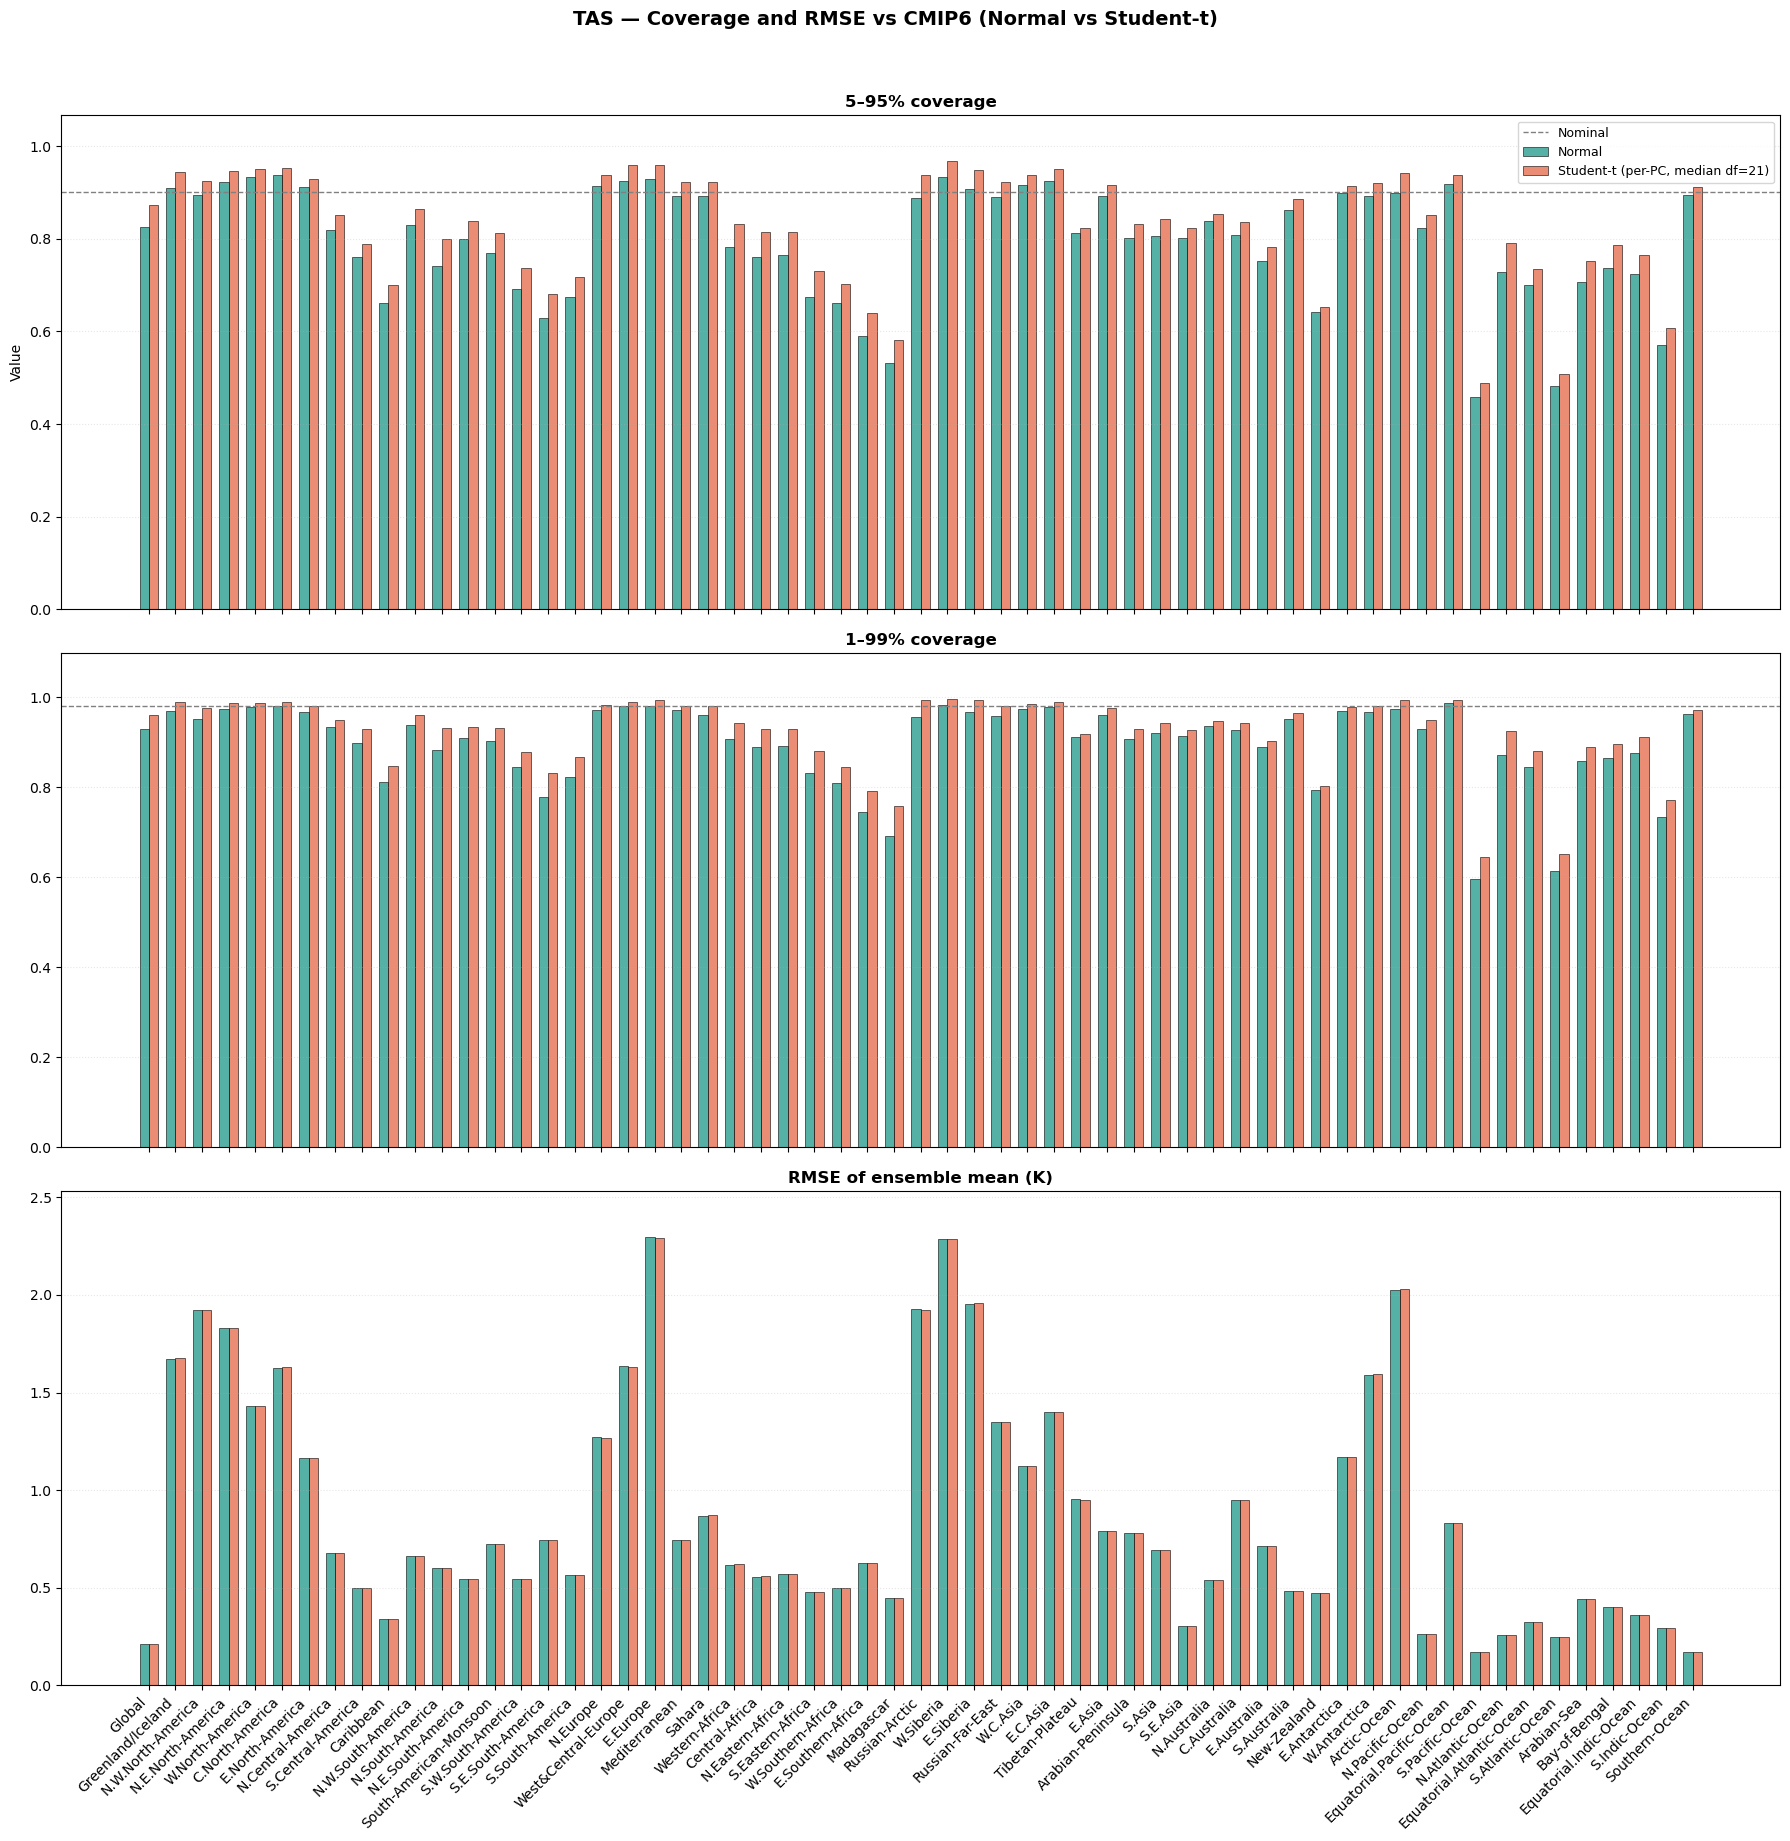

In [24]:
# 7. Plotting functions for table values
# ----------------------------------------------------------------------
def plot_coverage_benchmark(coverage_benchmark, region_names, save=True):
    """
    Visualise coverage_5_95, coverage_1_99 and rmse_mean
    for Normal vs Student-t, per region (including Global).

    Uses the values from results['coverage_benchmark'] produced in
    quantify_model_differences_and_benchmark.

    The plots are analogous in style to the tail-ratio and time-series
    comparison figures in the investigation notebook:
      - multi-panel, one metric per panel
      - per-region bars for Normal vs Student-t
    <ref: index={3075979} firstWord={1} lastWord={80}/>
    """
    df = coverage_benchmark.copy()

    # Sort locations for consistent ordering
    # 'global' first, then AR6 regions in the order of region_names
    loc_order = ['global'] + [f'regional:{abbr}' for abbr in region_names.keys()]
    df['location'] = pd.Categorical(df['location'], categories=loc_order, ordered=True)
    df = df.sort_values(['location', 'ensemble'])

    # Pretty labels: use 'Global' then AR6 names
    pretty_label = {}
    for loc in df['location'].unique():
        if loc == 'global':
            pretty_label[loc] = 'Global'
        else:
            abbr = loc.split(':', 1)[1]
            pretty_label[loc] = region_names.get(abbr, abbr)

    # Pivot so we have ensemble as columns, location as index
    # e.g. coverage_5_95: rows=locations, cols=Normal / Student-t
    cov_90 = df.pivot(index='location', columns='ensemble', values='coverage_5_95')
    cov_98 = df.pivot(index='location', columns='ensemble', values='coverage_1_99')
    rmse   = df.pivot(index='location', columns='ensemble', values='rmse_mean')

    # Order index (in case some regions are missing)
    cov_90 = cov_90.loc[[loc for loc in loc_order if loc in cov_90.index]]
    cov_98 = cov_98.loc[[loc for loc in loc_order if loc in cov_98.index]]
    rmse   = rmse.loc[[loc for loc in loc_order if loc in rmse.index]]

    # X positions
    locs = cov_90.index.tolist()
    x = np.arange(len(locs))
    width = 0.35

    ensembles = cov_90.columns.tolist()
    if len(ensembles) != 2:
        print("Expected exactly two ensembles (Normal and Student-t). Found:", ensembles)
    # Maintain the existing colour coding from the notebook:
    # Normal -> '#2A9D8F', Student-t -> '#E76F51'
    colors = {
        'Normal': '#2A9D8F',
        t_label: '#E76F51',
    }

    fig, axes = plt.subplots(3, 1, figsize=(18, 18), sharex=True)
    metrics = [
        (cov_90, 'coverage_5_95', '5–95% coverage', 0.9),
        (cov_98, 'coverage_1_99', '1–99% coverage', 0.98),
        (rmse,   'rmse_mean',     'RMSE of ensemble mean (K)', None),
    ]

    for ax, (mat, col_name, title, nominal) in zip(axes, metrics):
        # Bars: Normal left, Student-t right
        for i, ens in enumerate(mat.columns):
            offset = (-0.5 + i) * width
            ax.bar(
                x + offset,
                mat[ens].values,
                width=width,
                color=colors.get(ens, '#999999'),
                edgecolor='black',
                lw=0.5,
                label=ens if ax is axes[0] else None,  # show legend only once
                alpha=0.8,
            )

        if nominal is not None:
            ax.axhline(nominal, color='grey', ls='--', lw=1,
                       label='Nominal' if ax is axes[0] else None)

        ax.set_title(title, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y', ls=':')
        ax.set_xticks(x)
        ax.set_xticklabels([pretty_label[loc] for loc in locs], rotation=45, ha='right')

        # Slight padding for y-axis
        ymin, ymax = ax.get_ylim()
        ax.set_ylim([max(0, ymin), ymax * 1.05])

    axes[0].set_ylabel('Value')
    axes[0].legend(fontsize=9)
    fig.suptitle('TAS — Coverage and RMSE vs CMIP6 (Normal vs Student-t)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save:
        out_path = os.path.join(FIGURE_DIR, 'student_t_coverage_benchmark_tas.pdf')
        plt.savefig(out_path, bbox_inches='tight', dpi=200)
        print("Saved coverage benchmark figure to:", out_path)

    plt.show()


# Example usage: call right after results are computed
plot_coverage_benchmark(results['coverage_benchmark'], region_names)
